In [1]:
import pandas as pd
import collections
import plotnine as p9
p9.theme_set(p9.theme_bw)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # umap doesn't load :(

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import calcutta
import scipy.sparse as sp
import scipy.io
import re
import calcutta
from importlib import reload
reload(calcutta)

def sparse_sum(x, dim):
    return np.squeeze(np.asarray(x.sum(dim)))


## Check coverage per cell

This code should all also work when using t2t_dedup (i.e. isoform level counts). 

In [3]:
data_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice")
#salmon_dir = data_dir / "salmon_spliceu" / "out_permit_known" / "quant_t2t_dedup" 
salmon_dir = data_dir / "salmon_spliceu" / "out_permit_known" / "quant_spliceu_t2g"

cells_meta = pd.read_csv(salmon_dir / "featureDump.txt", sep = "\t")
cells_meta.shape # 192k cells in OG split-seq, 79k in microglia_less (30k according to paper, but these might be "half cells")
# 744k when using known BCs (!) for microglialess

(744997, 9)

Text(0.5, 0, 'log10(deduped reads)')

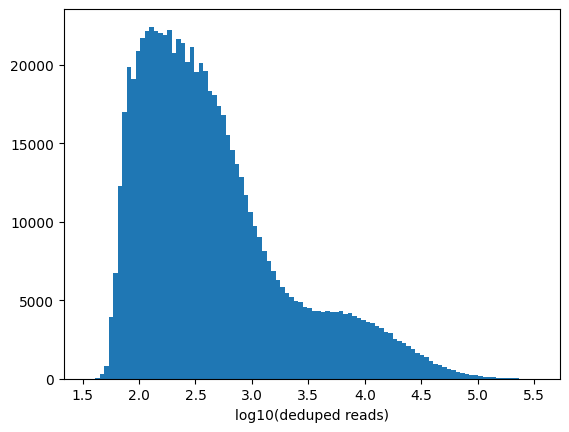

In [4]:
plt.hist(np.log10(cells_meta.DeduplicatedReads), 100)
plt.xlabel("log10(deduped reads)")

I think just the fat right tail are the real cells. 

In [4]:
np.median(cells_meta.DeduplicatedReads) 
# only 300 when using known BCs: this is just because there are so many fake(?) low count cells

326.98822

## Check barcodes

Get barcodes, these are the same for each round for V1 Split-seq. For Parse ("V2") the RT BCs are different from the ligation ones. 

In [5]:
polydT_hex_pairs_v1 = pd.read_csv("splitseqv1_meta/oligo_hex_bc_mapping.txt", sep = "\t" )
polydT_hex_pairs_v1.columns = ["polydT", "hex"]
polydT_hex_pairs_v1.head()

,polydT,hex
0,AACGTGAT,GATAGACA
1,AAACATCG,GCCACATA
2,ATGCCTAA,GCGAGTAA
3,AGTGGTCA,GCTAACGA
4,ACCACTGT,GCTCGGTA


In [6]:
valid_bcs_v1 = polydT_hex_pairs_v1.polydT.tolist() + polydT_hex_pairs_v1.hex.tolist()

In [7]:
# get the Parse/V2 barcodes (thanks Scott!) 
parse_meta_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/Parse_meta")
ligation_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_ligation_barcodes.txt", sep = "\t", header = None)
ligation_BCs_v2 = ligation_BCs_v2[0].tolist() 
ligation_BCs_v2[:5]

['AACGTGAT', 'AAACATCG', 'ATGCCTAA', 'AGTGGTCA', 'ACCACTGT']

In [8]:
len(set(ligation_BCs_v2) & set(valid_bcs_v1)) # these match

96

In [9]:
rt_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_RT_barcodes.txt", sep = "\t", header = None)
rt_BCs_v2 = rt_BCs_v2[0].tolist() 
len(rt_BCs_v2) # 96 barcodes (the order matters!)

96

In [10]:
len(set(rt_BCs_v2) & set(valid_bcs_v1)) # no overlap

0

In [11]:
# Check which cells have valid barcodes. If using permit_known this will be all of them. 
valid_counter = collections.Counter()
to_keep = np.zeros(cells_meta.shape[0], dtype=bool)
for i,bc in enumerate(cells_meta.CB):
    hit1 = bc[:8] in valid_bcs_v1
    hit2 = bc[8:16] in valid_bcs_v1
    hit3 = bc[16:] in rt_BCs_v2
    to_keep[i] = hit1 and hit2 and hit3
    valid_counter[ (hit1,hit2,hit3)] += 1 

valid_counter 
# 77750 valid BCs for microglialess w/ permit knee
# all valid when using known BCs

Counter({(True, True, True): 744997})

In [12]:
valid_counter[(True,True,True)] / len(cells_meta) # 98% valid for both datasets (OG and microglialess) when using permit_knee

1.0

In [13]:
# it was just a guess that this ordering is correct but it seems to be
polydT_hex_pairs_v2 = pd.DataFrame({"rnd1_BC" : rt_BCs_v2, "rnd1_well" : np.tile(np.arange(48), 2), "polydT" : [True] * 48 + [False] * 48}) 
ligation_BC_v2_dict = dict(zip(ligation_BCs_v2, np.arange(96)))

In [14]:
# extract the individual parts of the cell barcode
cells_meta["rnd3_BC"] = cells_meta.CB.str[:8]
cells_meta["rnd2_BC"] = cells_meta.CB.str[8:16]
cells_meta["rnd1_BC"] = cells_meta.CB.str[16:]

# convert to well IDs
cells_meta["rnd2_well"] = cells_meta["rnd2_BC"].map(ligation_BC_v2_dict)
cells_meta["rnd3_well"] = cells_meta["rnd3_BC"].map(ligation_BC_v2_dict)

cells_meta = pd.merge(cells_meta, polydT_hex_pairs_v2, on = "rnd1_BC")

In [15]:
# used to keep track of what the corresponding row in the count matrix is
cells_meta = cells_meta.reset_index(names = "og_index")

In [16]:
# build the mapping between the polydT and ranhex "half" cells
cells_meta_select = cells_meta[ ['og_index', 'CB', 'rnd3_well', 'rnd2_well', 'rnd1_well'] ]
polydT_halfcells = cells_meta_select[cells_meta.polydT]
ranhex_halfcells = cells_meta_select[~cells_meta.polydT]
polydT_ranhex_map = pd.merge(polydT_halfcells, ranhex_halfcells, on = ['rnd3_well', 'rnd2_well', 'rnd1_well'], how = 'inner', suffixes = ["_polydT","_ranhex"])
polydT_ranhex_map.head()

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,og_index_ranhex,CB_ranhex
0,9216,CCGACAACTGGTGGTACTATTTCA,85,66,45,267561,CCGACAACTGGTGGTAATCTATAA
1,9217,CCATCCTCACACAGAACTATTTCA,84,17,45,267567,CCATCCTCACACAGAAATCTATAA
2,9218,AACGCTTAAGTCACTACTATTTCA,14,26,45,267560,AACGCTTAAGTCACTAATCTATAA
3,9219,CATCAAGTAGCAGGAACTATTTCA,7,25,45,267568,CATCAAGTAGCAGGAAATCTATAA
4,9220,ATCATTCCACACAGAACTATTTCA,80,17,45,267562,ATCATTCCACACAGAAATCTATAA


## Read cells x genes count matrix

In [17]:
# read the counts matrix. cache in a binary format for faster loading. this take a while the first time. 
cache_file = salmon_dir / "alevin" / "quants_mat.npz"
if cache_file.exists(): 
    count_mat = scipy.sparse.load_npz(cache_file)
else: 
    count_mat = scipy.io.mmread(salmon_dir / "alevin" / "quants_mat.mtx") # cells x genes
    scipy.sparse.save_npz(cache_file, count_mat)

In [18]:
count_sub = count_mat.tocsr()[to_keep,:] # only keep valid BCs

In [19]:
genes = [ g.strip() for g in open(salmon_dir / "alevin" / "quants_mat_cols.txt","r").readlines() ]
genes[:5] # these are transcripts if using t2t

['ENSMUST00000000514.11',
 'ENSMUST00000001027.7',
 'ENSMUST00000001166.14',
 'ENSMUST00000003219.14',
 'ENSMUST00000004829.13']

In [20]:
genes[-5:] # -I means precursor I think? not these are for the GENE not the isoform

['ENSMUSG00000102011.2-I',
 'ENSMUSG00000100964.2-I',
 'ENSMUSG00000099619.7-I',
 'ENSMUSG00000099399.7-I',
 'ENSMUSG00000095366.3-I']

In [21]:
set([ g.split("-")[-1] for g in genes if "-" in g]) # just I for t2t

{'I'}

In [22]:
gene_sums = calcutta.sparse_sum(count_sub,0)

In [23]:
#is_precursor = np.array([ ("-I" in g) for g in genes ])
cleaner = lambda g: g.group(1) if g else "S" # S for Spliced
align_type = np.array([ cleaner(re.search(r'-(.*)', g)) for g in genes ])
align_type

array(['S', 'S', 'S', ..., 'I', 'I', 'I'], dtype='<U1')

/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 9071 rows containing non-finite values.


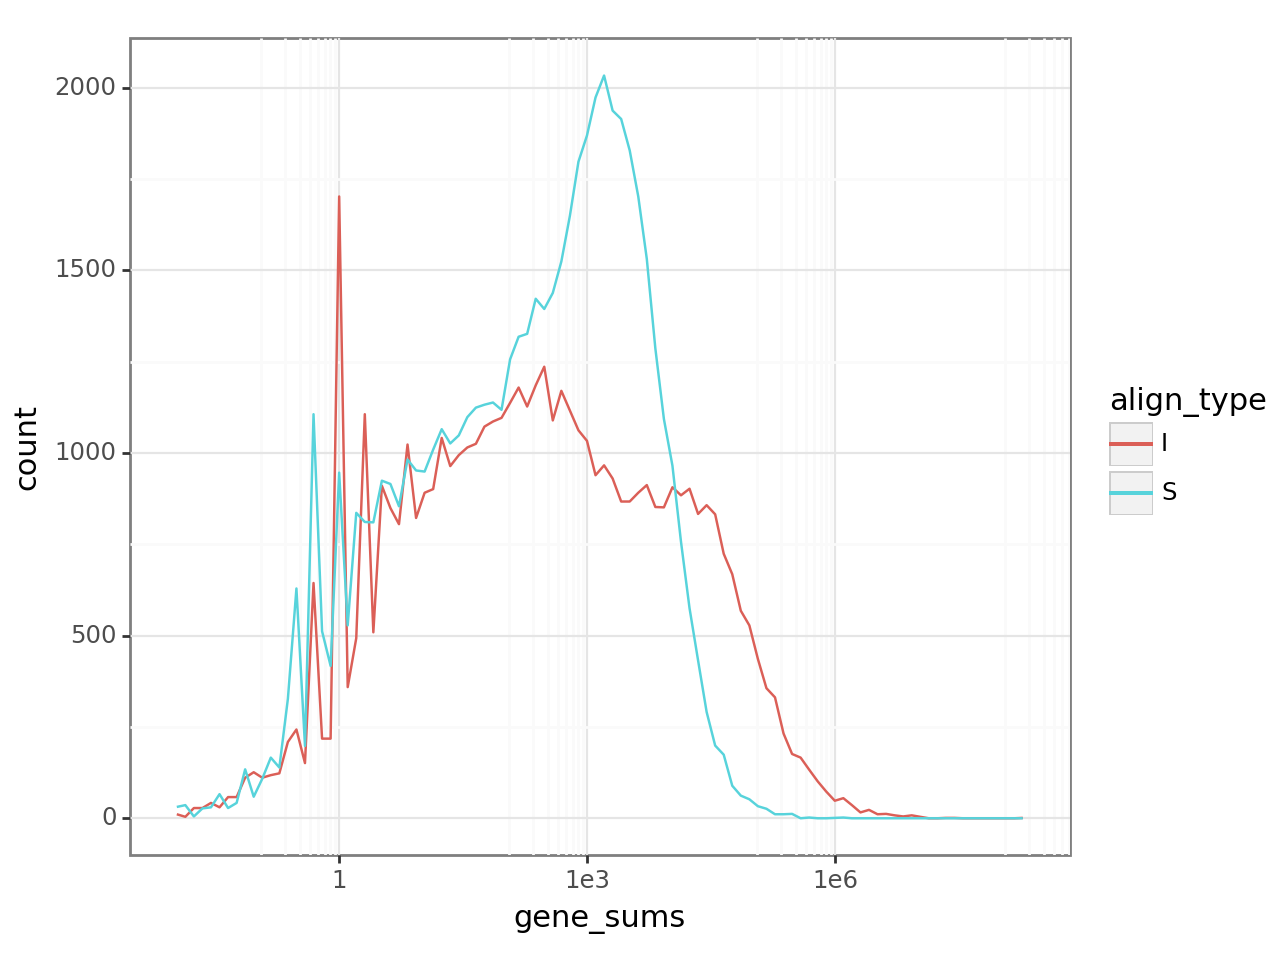

<Figure Size: (640 x 480)>

In [24]:
to_plot = pd.DataFrame({"gene_sums" : gene_sums, "align_type" : align_type})
p9.ggplot(to_plot, p9.aes("gene_sums", color = "align_type")) + p9.scale_x_log10() + p9.geom_freqpoly(bins = 100)  

## Combine counts

In [25]:
polydT_counts = count_mat.tocsr()[polydT_ranhex_map.og_index_polydT,:]
ranhex_counts = count_mat.tocsr()[polydT_ranhex_map.og_index_ranhex,:]
comb_counts = polydT_counts + ranhex_counts

In [26]:
gene_sum = sparse_sum(comb_counts, 0)
cell_sum = sparse_sum(comb_counts, 1)

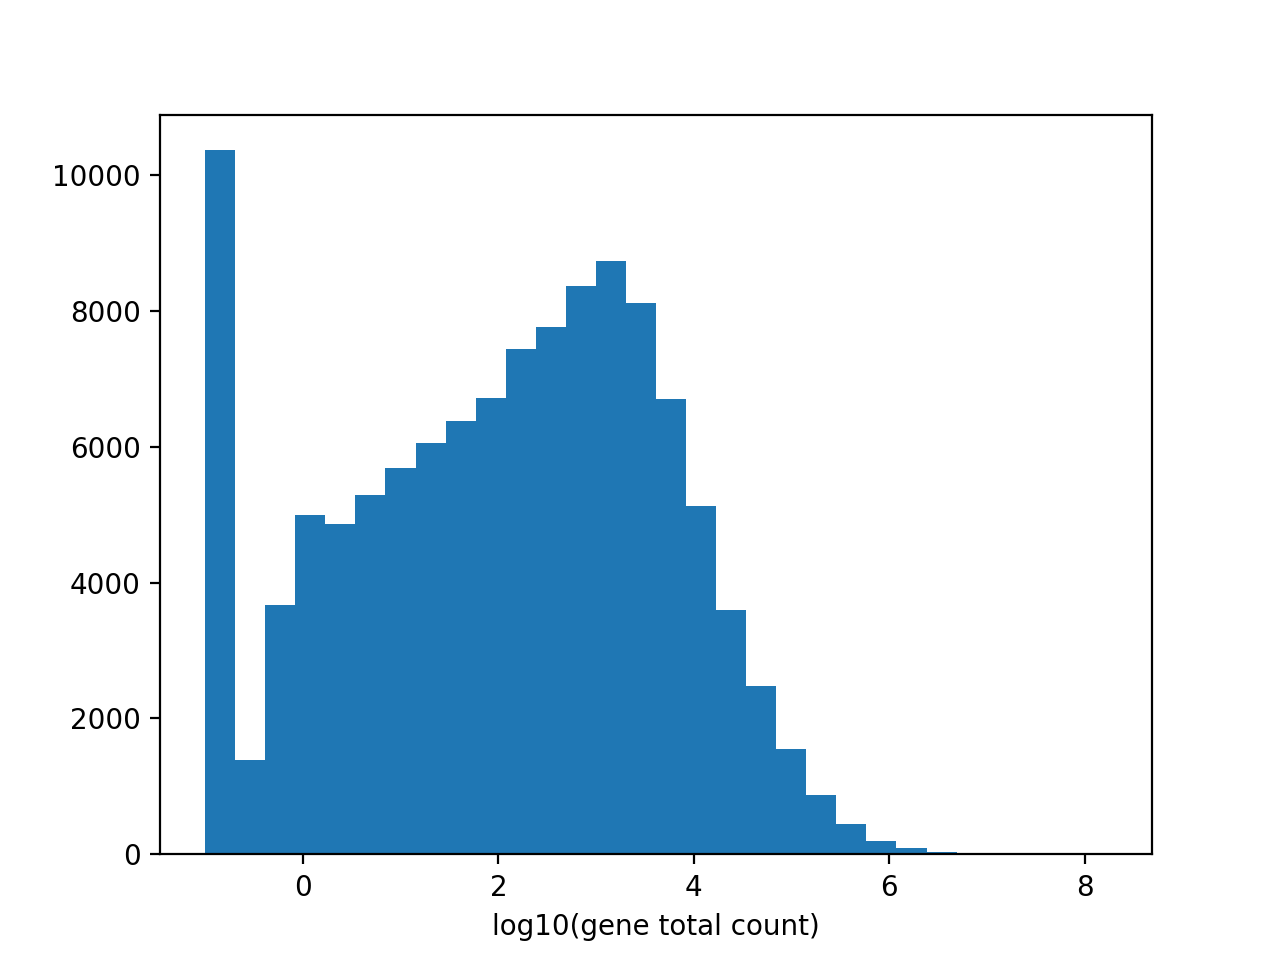

In [27]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

104.99422182

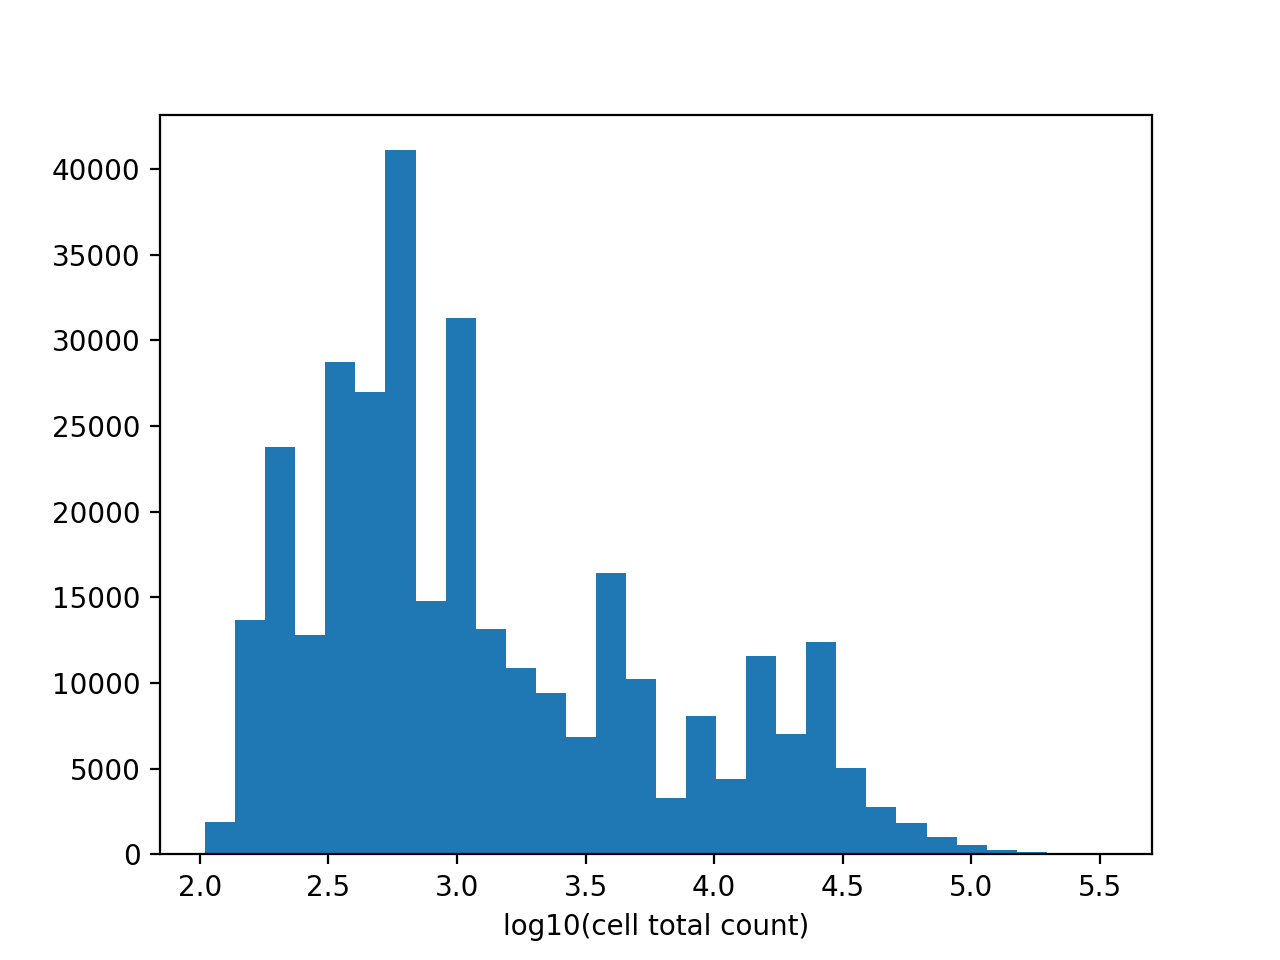

In [28]:
plt.hist(np.log10(cell_sum), 30) # there are a LOT of cells with ~900 reads. 
plt.xlabel("log10(cell total count)")
cell_sum.min()

In [29]:
cells_to_keep = np.logical_and(cell_sum > 1000, cell_sum < 1e5) 
cells_to_keep.sum() # 140k seems v high

145072

In [30]:
# a more sensible analysis would probably filter somewhat on total count and then further on variance, but this is simpler
genes_to_keep = gene_sum > 30000
genes_to_keep.sum()

6281

In [31]:
count_sub = count_mat.tocsr()[cells_to_keep,:]
count_sub = count_sub[:,genes_to_keep]

# seurat default normalization (i believe)
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 
ge = np.log10(rat.toarray() + 1.)

In [32]:
# center and scale
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

Text(0, 0.5, 'PC2')

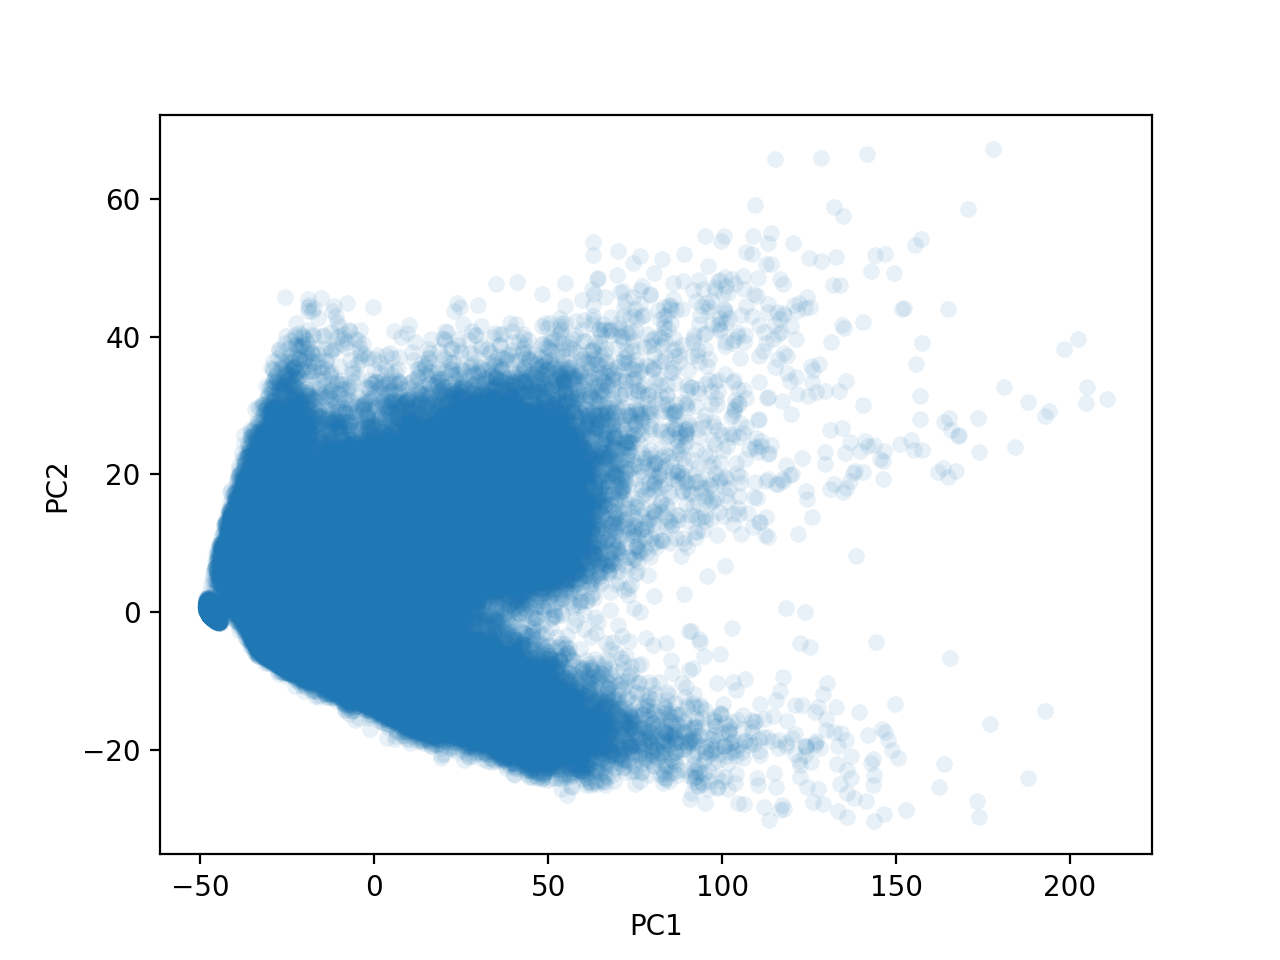

In [33]:
sns.scatterplot(low_rank_data[:,0], low_rank_data[:,1], linewidth=0, alpha = 0.1)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [34]:
tsne = TSNE(n_components=2)
embedding = tsne.fit_transform(low_rank_data)

AttributeError: 'NoneType' object has no attribute 'split'

<Axes: >

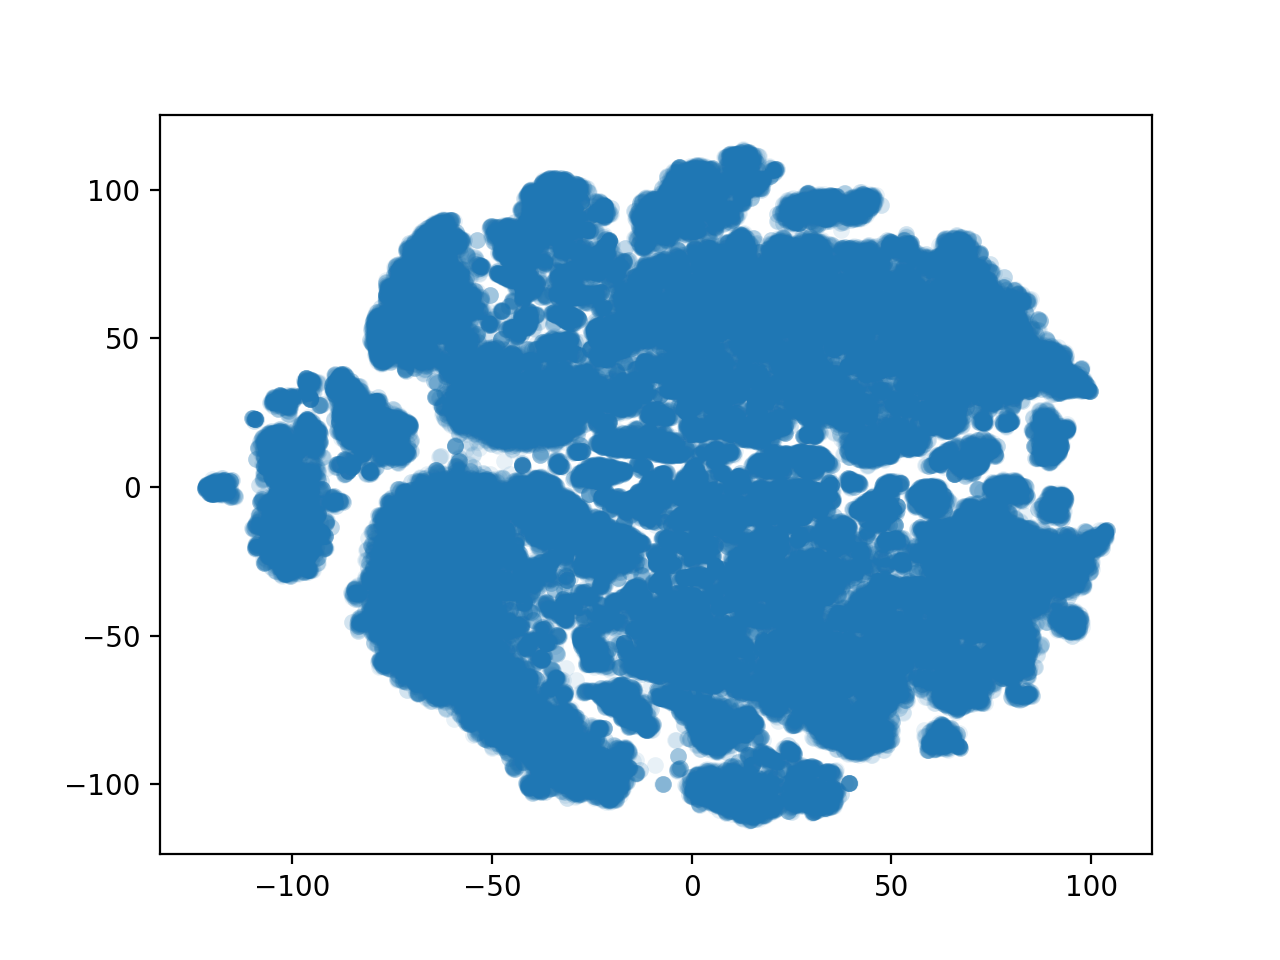

In [35]:
sns.scatterplot(embedding[:,0], embedding[:,1], linewidth=0, alpha = 0.1)
# some structure but also kinda a mess: too many v low count cells

## Align with preprocessed data

The paper provided preprocessed data which we align our analysis with here: 

In [36]:
preproc_BCs_id = [ g.strip() for g in open(data_dir / "GSM5693472_barcodes.tsv","r").readlines() ]
preproc_BCs = [ g.split("_")[0] for g in preproc_BCs_id ]
preproc_BCs_id[:5] # these are [rnd3 BC][rnd2 BC]_[rnd1 well ID]_[sublib ID]

['TTCACGCAACGCTCGA_7_1',
 'AAGACGGAAACGCTTA_8_1',
 'CCATCCTCACCTCCAA_30_1',
 'CCTCTATCCGACTGGA_24_1',
 'GCTAACGACAAGACTA_23_1']

In [37]:
RT_BC_index = [ int(g.split("_")[1]) for g in preproc_BCs_id ]
set(RT_BC_index) == set(range(48)) # 48 rnd1 wells

True

In [38]:
sublib_index = [ g.split("_")[2] for g in preproc_BCs_id ]
set(sublib_index)  # 8 sublibs

{'1', '2', '3', '4', '5', '6', '7', '8'}

In [39]:
preproc_cellmeta = pd.read_csv(data_dir / "GSM5693472_cell_metadata.txt.gz", sep = "\t")
preproc_cellmeta.head()

,nCount_RNA,nFeature_RNA,sample,rnd1_well,rnd2_well,rnd3_well,sublibrary,RNA.Nuclei.Group,Age,Sex,Sac,Dissection.Batch,DX,RIN,percent.mt,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters
0,19978,4489,E-7,7,20,67,ACTTGA,Group1,5.115,M,8/19/2020,2,5xFIRE + PBS,8.8,0.020022,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
1,19974,4923,F-7,8,14,15,ACTTGA,Group2,5.082,M,8/12/2020,2,5xFIRE + transplant,8.3,0.590768,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain
2,19966,4589,C-6,30,19,84,ACTTGA,Group4,5.049,M,11/14/2019,1,FIRE,7.6,0.030051,EX,EX thalamus,16-EX thalamus,15-EX thalamus,EX thalamus
3,19949,4476,F-2,24,40,87,ACTTGA,Group4,5.049,F,8/12/2020,2,5xFIRE + transplant,8.7,0.060153,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
4,19941,5197,F-5,23,46,51,ACTTGA,Group3,5.148,M,7/23/2020,2,5xFIRE + transplant,8.3,0.235695,VLMC,VLMC,27-VLMC,NaN,VLMC


In [40]:
preproc_cellmeta.rnd1_well.max() 
# only 48 entries (zero indexed!) compared to 96 for rnd2 and rnd3. So hex+polydT already combined. 

47

In [41]:
preproc_cellmeta["rnd3_BC"] = [ g[:8] for g in preproc_BCs ]
preproc_cellmeta["rnd2_BC"] = [ g[8:] for g in preproc_BCs ]
preproc_cellmeta["sublib_BC"] = [ g.split("_")[2] for g in preproc_BCs_id ]

In [42]:
tab_BC2 = preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size() # correct, and gives mapping
tab_BC2 = tab_BC2.reset_index()
tab_BC2 = tab_BC2.sort_values("rnd2_well")

In [43]:
(tab_BC2.rnd2_BC == ligation_BCs_v2).all() # their BC ordering agrees with what we expect

True

In [44]:
tab_BC3 = preproc_cellmeta.groupby(["rnd3_BC","rnd3_well"]).size() # correct, and gives mapping (think ordering is what I have)
tab_BC3 = tab_BC3.reset_index()
tab_BC3 = tab_BC3.sort_values("rnd3_well")
tab_BC3.head()

,rnd3_BC,rnd3_well,0
4,AACGTGAT,0,537
0,AAACATCG,1,528
36,ATGCCTAA,2,542
32,AGTGGTCA,3,523
18,ACCACTGT,4,543


In [45]:
(tab_BC3.rnd3_BC == ligation_BCs_v2).all()

True

In [46]:
preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size()

rnd2_BC   rnd2_well
AAACATCG  1            574
AACAACCA  12           535
AACCGAGA  13           520
AACGCTTA  14           524
AACGTGAT  0            541
                      ... 
TGAAGAGA  63           497
TGGAACAA  64           534
TGGCTTCA  65           571
TGGTGGTA  66           553
TTCACGCA  67           554
Length: 96, dtype: int64

In [47]:
preproc_cellmeta.groupby(["sublibrary","sublib_BC"]).size() # correct

sublibrary  sublib_BC
ACTTGA      1            4570
AGTCAA      2            8132
AGTTCC      3            7749
CAGATC      4            4777
CTTGTA      5            7613
GATCAG      6            4992
GGCTAC      7            6702
TAGCTT      8            6792
dtype: int64

In [48]:
ligation_BCs_v2 = np.array(ligation_BCs_v2)
rt_BCs_v2 = np.array(rt_BCs_v2)

# build the full cell BCs for the preproc data
rnd3_rnd2 = np.char.add( 
    ligation_BCs_v2[ preproc_cellmeta.rnd3_well.to_numpy() ],
    ligation_BCs_v2[ preproc_cellmeta.rnd2_well.to_numpy() ] )

preproc_cellmeta["full_BC_polydT"] = np.char.add( rnd3_rnd2, rt_BCs_v2[ preproc_cellmeta.rnd1_well.to_numpy() ] )
preproc_cellmeta["full_BC_ranhex"] = np.char.add( rnd3_rnd2, rt_BCs_v2[48:][ preproc_cellmeta.rnd1_well.to_numpy() ] )

In [49]:
len(set(preproc_cellmeta.full_BC_ranhex) & set(preproc_cellmeta.full_BC_polydT)) # 0, good

0

In [50]:
len(set(cells_meta.CB) & set(preproc_cellmeta.full_BC_polydT)) # 21k with knee, 47.5k with known

47498

In [51]:
len(set(cells_meta.CB) & set(preproc_cellmeta.full_BC_ranhex)) # 17k with knee, 47.5k with known

47495

In [52]:
BC_counts = preproc_cellmeta.full_BC_polydT.value_counts()
BC_counts.reset_index()["count"].value_counts() 
# surprising to me that 8% of cells appear to have the same first 3 BCs and only separate with the sublib BC

count
1    43923
2     3335
3      226
4       14
Name: count, dtype: int64

In [53]:
# these are barcodes with no collisions
safe_BCs = BC_counts[BC_counts==1].index.tolist()
safe_BCs[:5]

['TGGCTTCAGTACGCAATTGTCTTA',
 'GCCACATATCTTCACATACTCGAA',
 'GCTCGGTACAAGGAGCATTCATGG',
 'CCTAATCCCGCTGATCTCACTTTA',
 'AACTCACCACCTCCAAGAGCACAA']

In [54]:
preproc_cellmeta_safe = preproc_cellmeta[ preproc_cellmeta.full_BC_polydT.isin(safe_BCs) ]

In [55]:
preproc_cellmeta_safe.shape

(43923, 25)

In [56]:
polydT_merge = pd.merge(cells_meta, preproc_cellmeta_safe, left_on = "CB", right_on = "full_BC_polydT", how = "inner")
ranhex_merge = pd.merge(cells_meta, preproc_cellmeta_safe, left_on = "CB", right_on = "full_BC_ranhex", how = "inner")

In [57]:
meta_merged = pd.concat([polydT_merge, ranhex_merge])
meta_merged["polydT"] = meta_merged.CB == meta_merged.full_BC_polydT
meta_merged.head()

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,...,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters,rnd3_BC_y,rnd2_BC_y,sublib_BC,full_BC_polydT,full_BC_ranhex
0,9221,GTCGTAGACGCTGATCCTATTTCA,702228,611764,205851.64,0.871176,0.336489,0.001137,17252,2625,...,ASC,ASC,5-ASC,NaN,ASC,GTCGTAGA,CGCTGATC,5,GTCGTAGACGCTGATCCTATTTCA,GTCGTAGACGCTGATCATCTATAA
1,9224,GACAGTGCCACCTTACCTATTTCA,558099,488497,194520.53,0.875287,0.398202,0.000437,18646,2722,...,EX,EX hippocampus pyramidal,15-EX hippocampus pyramidal,NaN,EX hippocampus pyramidal,GACAGTGC,CACCTTAC,6,GACAGTGCCACCTTACCTATTTCA,GACAGTGCCACCTTACATCTATAA
2,9229,CCTAATCCCACCTTACCTATTTCA,541967,463824,173348.70,0.855816,0.373738,0.000432,17367,2435,...,EX,EX cortical,13-EX cortical L2/3,NaN,EX cortical,CCTAATCC,CACCTTAC,2,CCTAATCCCACCTTACCTATTTCA,CCTAATCCCACCTTACATCTATAA
3,9236,CATACCAACTGTAGCCCTATTTCA,433821,372412,146080.78,0.858446,0.392256,0.000979,16140,2398,...,EX,EX cerebellum granule,3-EX cerebellum granule,NaN,EX cerebellum granule,CATACCAA,CTGTAGCC,7,CATACCAACTGTAGCCCTATTTCA,CATACCAACTGTAGCCATCTATAA
4,9239,CGCATACACATACCAACTATTTCA,383490,335187,139829.08,0.874044,0.417167,0.000387,17179,2416,...,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain,CGCATACA,CATACCAA,7,CGCATACACATACCAACTATTTCA,CGCATACACATACCAAATCTATAA


In [58]:
meta_merged["polydT"].mean()

0.5000170759195383

In [59]:
comb_counts.shape

(320413, 116918)

In [60]:
polydT_ranhex_map 

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,og_index_ranhex,CB_ranhex
0,9216,CCGACAACTGGTGGTACTATTTCA,85,66,45,267561,CCGACAACTGGTGGTAATCTATAA
1,9217,CCATCCTCACACAGAACTATTTCA,84,17,45,267567,CCATCCTCACACAGAAATCTATAA
2,9218,AACGCTTAAGTCACTACTATTTCA,14,26,45,267560,AACGCTTAAGTCACTAATCTATAA
3,9219,CATCAAGTAGCAGGAACTATTTCA,7,25,45,267568,CATCAAGTAGCAGGAAATCTATAA
4,9220,ATCATTCCACACAGAACTATTTCA,80,17,45,267562,ATCATTCCACACAGAAATCTATAA
...,...,...,...,...,...,...,...
320408,744992,GTCGTAGAAGCACCTCATCCGCGA,56,76,9,712536,GTCGTAGAAGCACCTCTGGGCATC
320409,744993,ACCTCCAATGAAGAGAATCCGCGA,19,63,9,711924,ACCTCCAATGAAGAGATGGGCATC
320410,744994,CAACCACAGTACGCAAATCCGCGA,29,55,9,711224,CAACCACAGTACGCAATGGGCATC
320411,744995,CCTAATCCATCCTGTAATCCGCGA,86,27,9,712323,CCTAATCCATCCTGTATGGGCATC


In [61]:
preproc_cellmeta["no_collision"] = preproc_cellmeta.full_BC_polydT.isin(safe_BCs)


In [62]:
preproc_cellmeta.columns

Index(['nCount_RNA', 'nFeature_RNA', 'sample', 'rnd1_well', 'rnd2_well',
       'rnd3_well', 'sublibrary', 'RNA.Nuclei.Group', 'Age', 'Sex', 'Sac',
       'Dissection.Batch', 'DX', 'RIN', 'percent.mt', 'class', 'cluster_name',
       'clusternum_anno', 'clusters_4conditions', 'cellchat_clusters',
       'rnd3_BC', 'rnd2_BC', 'sublib_BC', 'full_BC_polydT', 'full_BC_ranhex',
       'no_collision'],
      dtype='object')

In [63]:
meta_meta = pd.merge( 
    polydT_ranhex_map, 
    preproc_cellmeta[ ["rnd1_well", "rnd2_well", "rnd3_well", "no_collision"] ].drop_duplicates(), 
    on = ["rnd1_well", "rnd2_well", "rnd3_well"], how = "left" )
meta_meta["cell_sum"] = sparse_sum(comb_counts, 1)

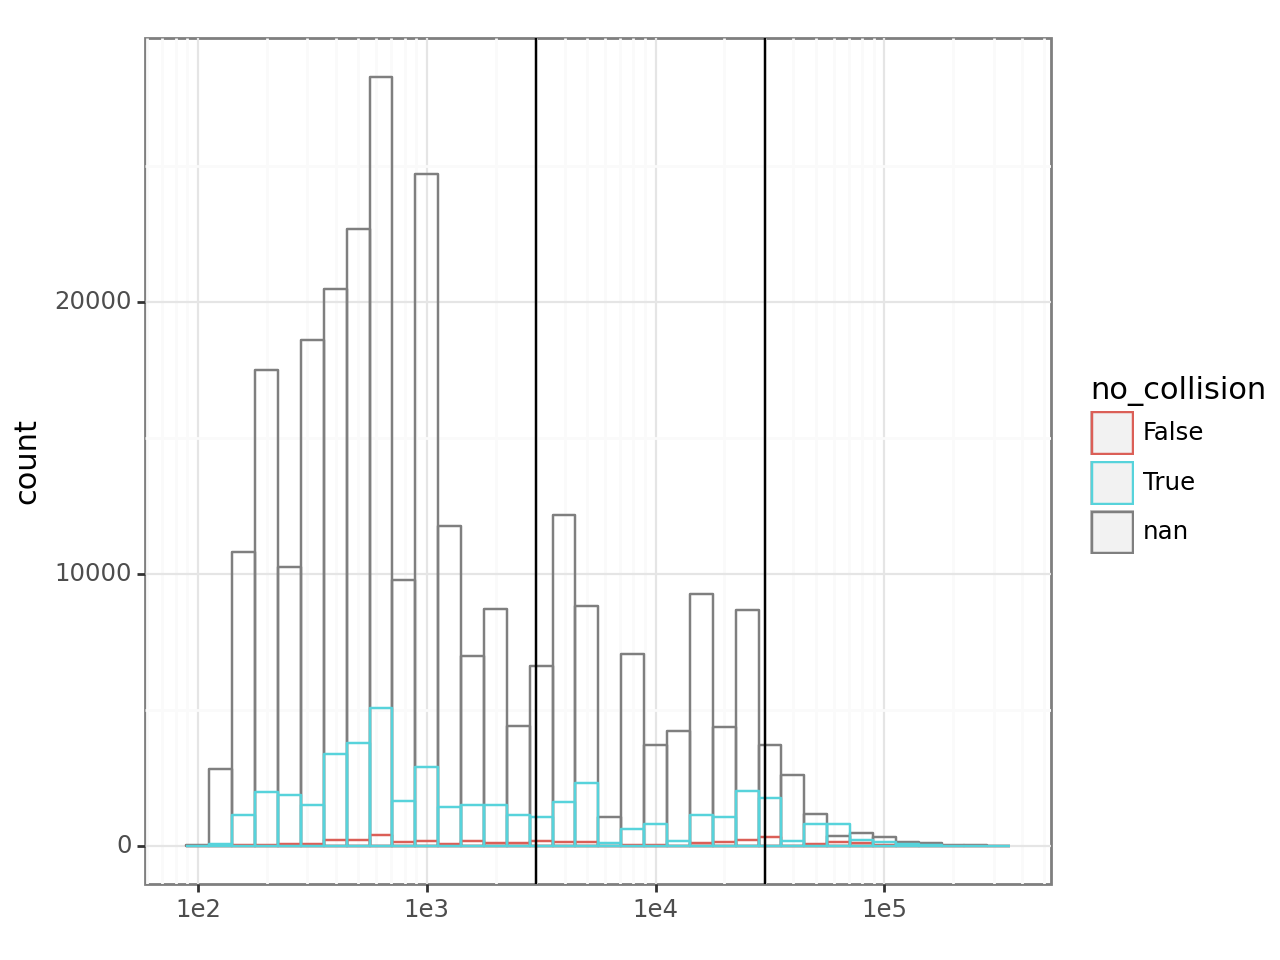

<Figure Size: (640 x 480)>

In [64]:
p9.ggplot(meta_meta, p9.aes(cell_sum,  color = "no_collision")) + p9.geom_histogram(position = "identity", fill = None, binwidth=0.1) + p9.scale_x_log10() + p9.geom_vline(xintercept = [3000,30000]) # what are all these "cells" with <1000 reads? 

In [65]:
meta_meta = pd.merge( 
    meta_meta, 
    preproc_cellmeta_safe[ ["rnd1_well", "rnd2_well", "rnd3_well", "class", 'cluster_name', 'clusternum_anno' ] ], 
    on = ["rnd1_well", "rnd2_well", "rnd3_well"], 
    how = "left" )

In [66]:
meta_meta.cluster_name.isna().mean()

0.862926909956837

In [67]:
meta_meta.shape

(320413, 12)

In [68]:
gene_sum = sparse_sum(comb_counts, 0)
cell_sum = sparse_sum(comb_counts, 1)

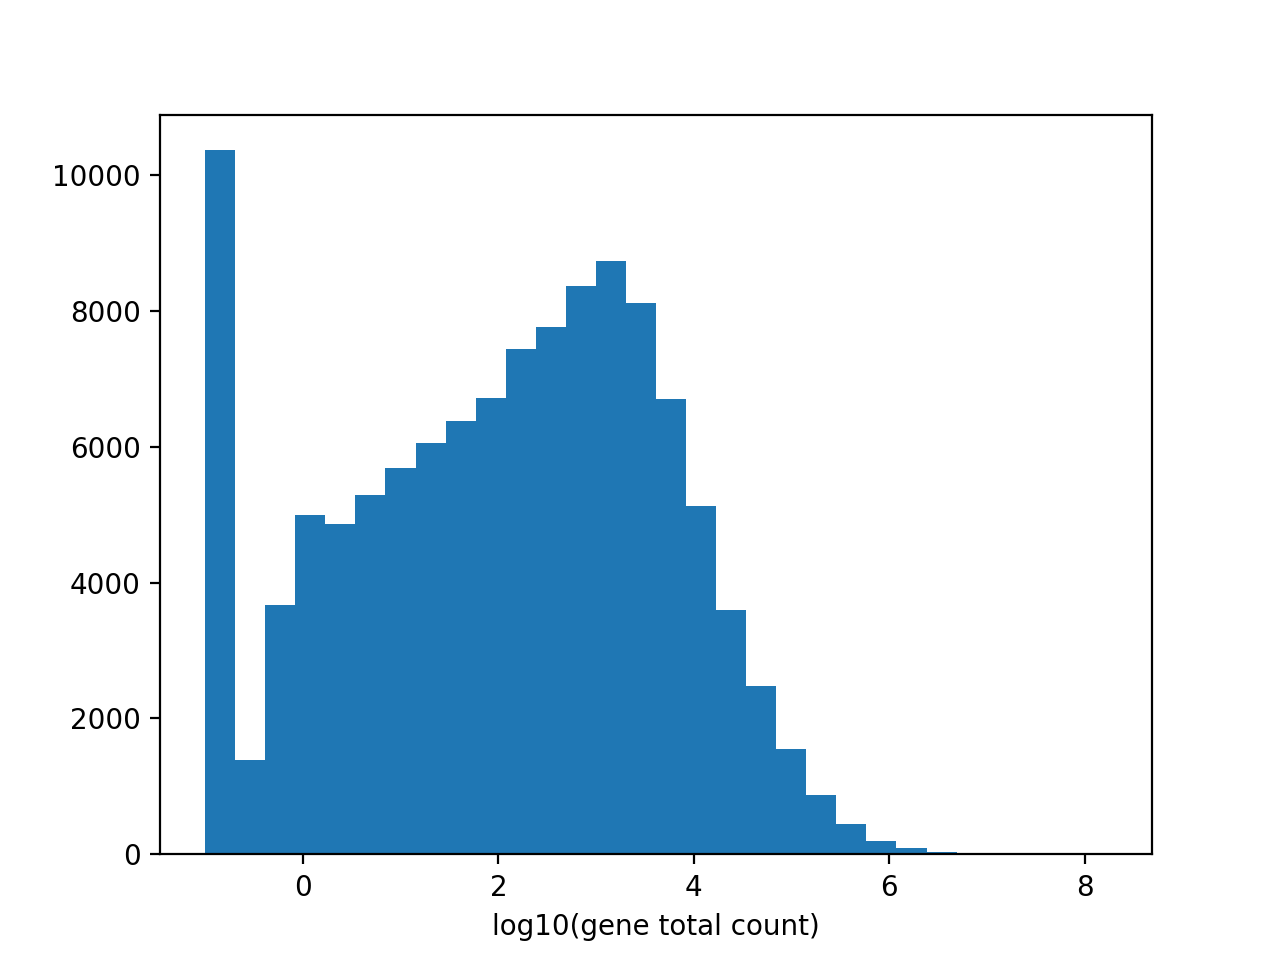

In [69]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

104.99422182

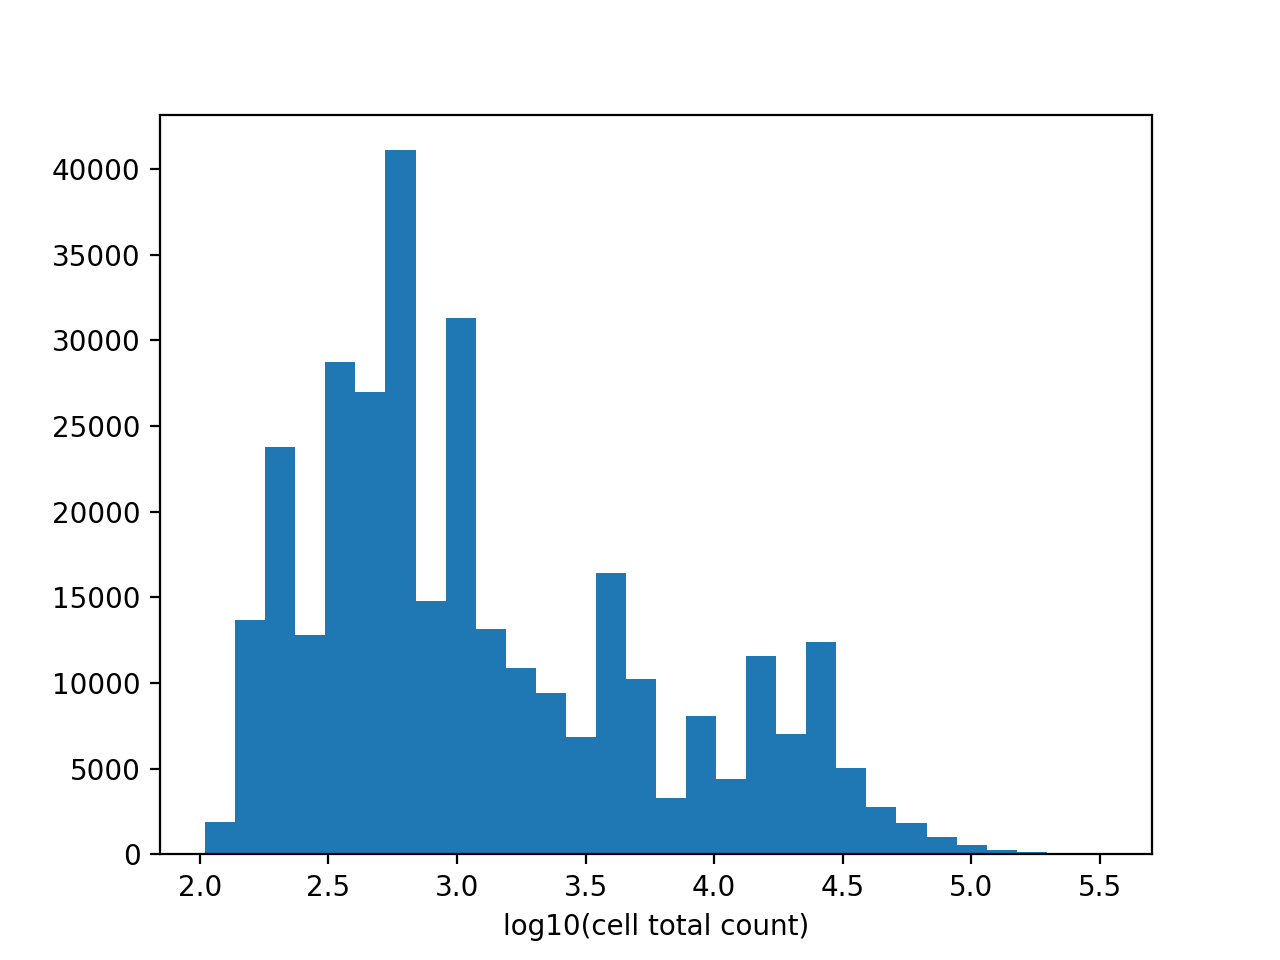

In [70]:
plt.hist(np.log10(cell_sum), 30)
plt.xlabel("log10(cell total count)")
cell_sum.min()

In [71]:

genes_to_keep = gene_sum > 20000
genes_to_keep.sum()

8332

In [72]:
cells_to_keep = np.logical_and(cell_sum > 3000, cell_sum < 3e4)
cells_to_keep.sum()

79588

In [73]:
count_sub = comb_counts[cells_to_keep,:]

In [74]:
count_sub = count_sub[:,genes_to_keep]


In [75]:
meta_sub = meta_meta[cells_to_keep]
meta_sub.head()

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,og_index_ranhex,CB_ranhex,no_collision,cell_sum,class,cluster_name,clusternum_anno
2,9218,AACGCTTAAGTCACTACTATTTCA,14,26,45,267560,AACGCTTAAGTCACTAATCTATAA,NaN,28692.718707,NaN,NaN,NaN
8,9224,GACAGTGCCACCTTACCTATTTCA,92,83,45,267565,GACAGTGCCACCTTACATCTATAA,True,26776.897968,EX,EX hippocampus pyramidal,15-EX hippocampus pyramidal
23,9239,CGCATACACATACCAACTATTTCA,41,34,45,267572,CGCATACACATACCAAATCTATAA,True,26649.974188,INH,INH midbrain,0-INH midbrain
25,9241,ACAGATTCGTACGCAACTATTTCA,74,55,45,267579,ACAGATTCGTACGCAAATCTATAA,True,28728.880472,INH,INH medium spiny,1-INH medium spiny
30,9246,CCATCCTCGTCTGTCACTATTTCA,84,57,45,267594,CCATCCTCGTCTGTCAATCTATAA,NaN,29178.888321,NaN,NaN,NaN


In [76]:
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 

In [77]:
ge = np.log10(rat.toarray() + 1.)

In [78]:
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

In [79]:
meta_sub

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,og_index_ranhex,CB_ranhex,no_collision,cell_sum,class,cluster_name,clusternum_anno
2,9218,AACGCTTAAGTCACTACTATTTCA,14,26,45,267560,AACGCTTAAGTCACTAATCTATAA,NaN,28692.718707,NaN,NaN,NaN
8,9224,GACAGTGCCACCTTACCTATTTCA,92,83,45,267565,GACAGTGCCACCTTACATCTATAA,True,26776.897968,EX,EX hippocampus pyramidal,15-EX hippocampus pyramidal
23,9239,CGCATACACATACCAACTATTTCA,41,34,45,267572,CGCATACACATACCAAATCTATAA,True,26649.974188,INH,INH midbrain,0-INH midbrain
25,9241,ACAGATTCGTACGCAACTATTTCA,74,55,45,267579,ACAGATTCGTACGCAAATCTATAA,True,28728.880472,INH,INH medium spiny,1-INH medium spiny
30,9246,CCATCCTCGTCTGTCACTATTTCA,84,57,45,267594,CCATCCTCGTCTGTCAATCTATAA,NaN,29178.888321,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
175605,405103,AGCACCTCCATCAAGTTACTCGAA,76,7,40,9094,AGCACCTCCATCAAGTTATCCGGG,NaN,27894.918799,NaN,NaN,NaN
175609,405107,TGAAGAGACAACCACATACTCGAA,63,29,40,9092,TGAAGAGACAACCACATATCCGGG,NaN,29615.739166,NaN,NaN,NaN
175610,405108,GCTAACGACTGGCATATACTCGAA,51,44,40,8886,GCTAACGACTGGCATATATCCGGG,NaN,27844.869405,NaN,NaN,NaN
175611,405109,GTCTGTCAACAAGCTATACTCGAA,57,9,40,8977,GTCTGTCAACAAGCTATATCCGGG,NaN,29647.903009,NaN,NaN,NaN


<Axes: >

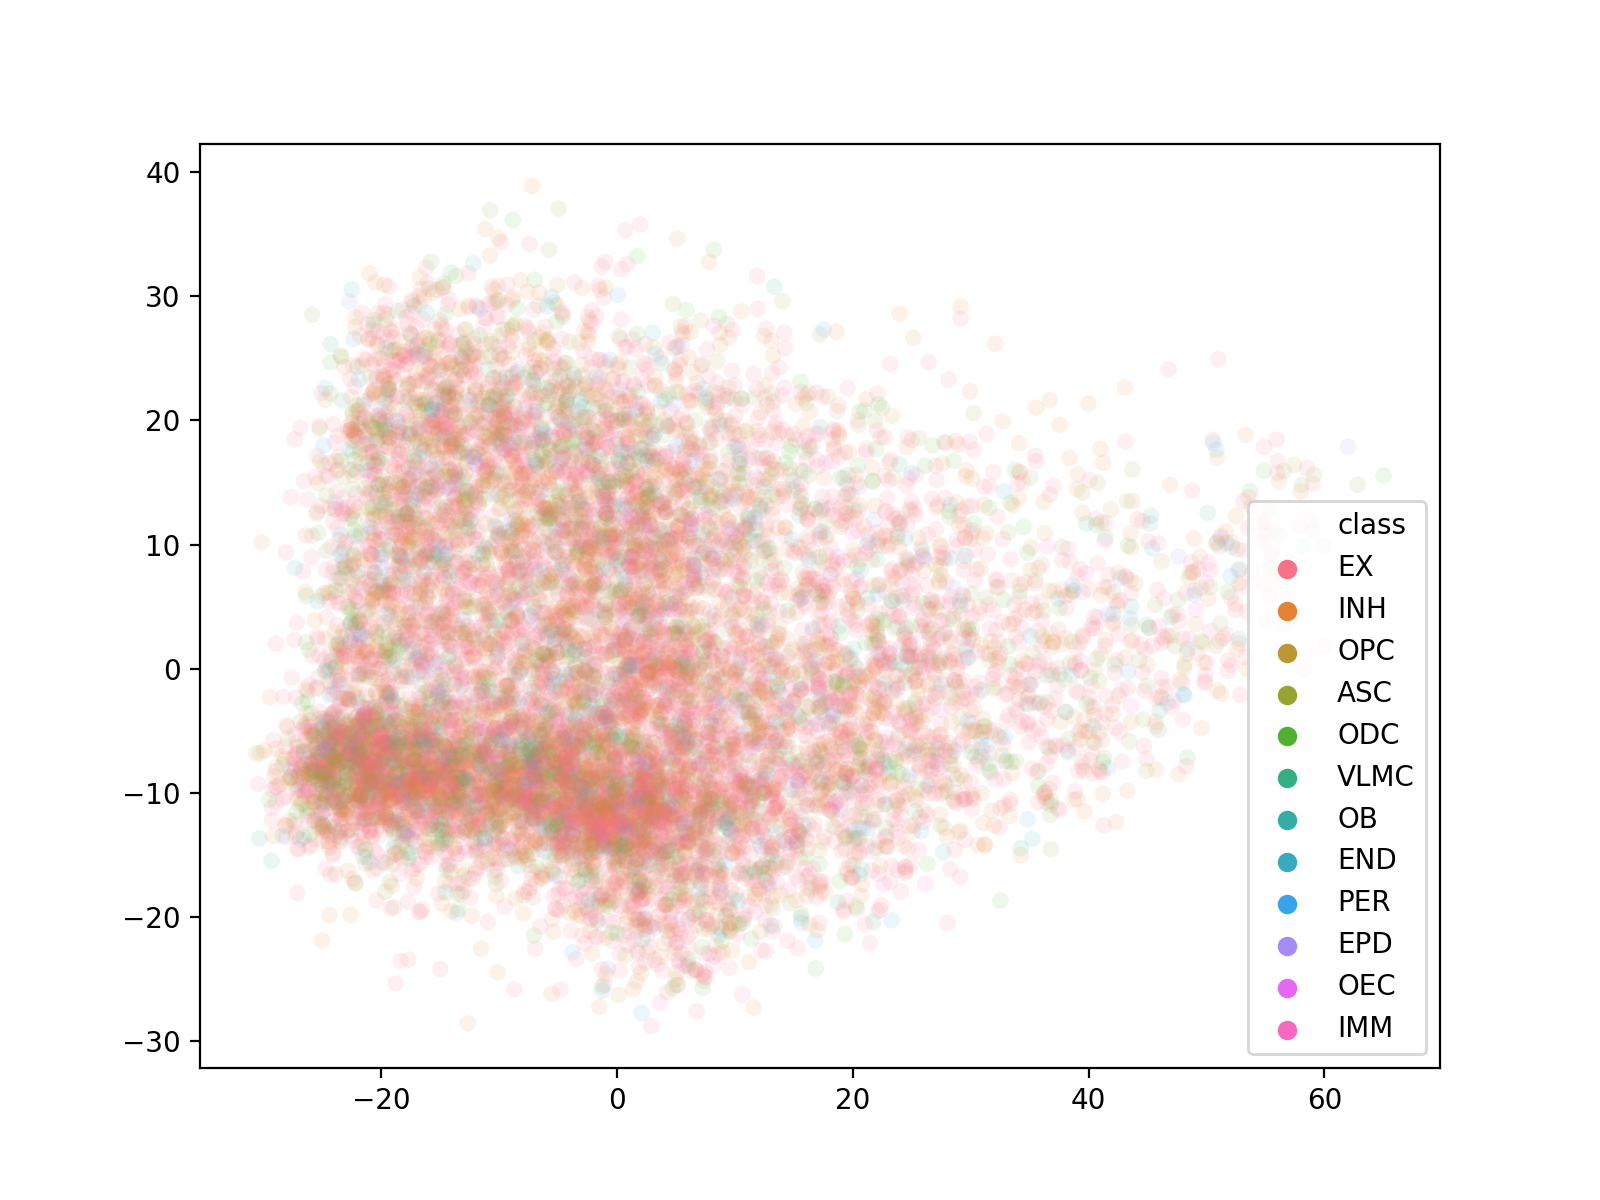

In [80]:
plt.figure(figsize=(8,6))
sns.scatterplot(low_rank_data[:,0], low_rank_data[:,1], hue = meta_sub["class"], linewidth=0, alpha = 0.1)

In [81]:
tsne = TSNE(n_components=2)
embedding = tsne.fit_transform(low_rank_data)

AttributeError: 'NoneType' object has no attribute 'split'

In [82]:
un = meta_sub["class"].isna()
un.mean()

0.8519374780117606

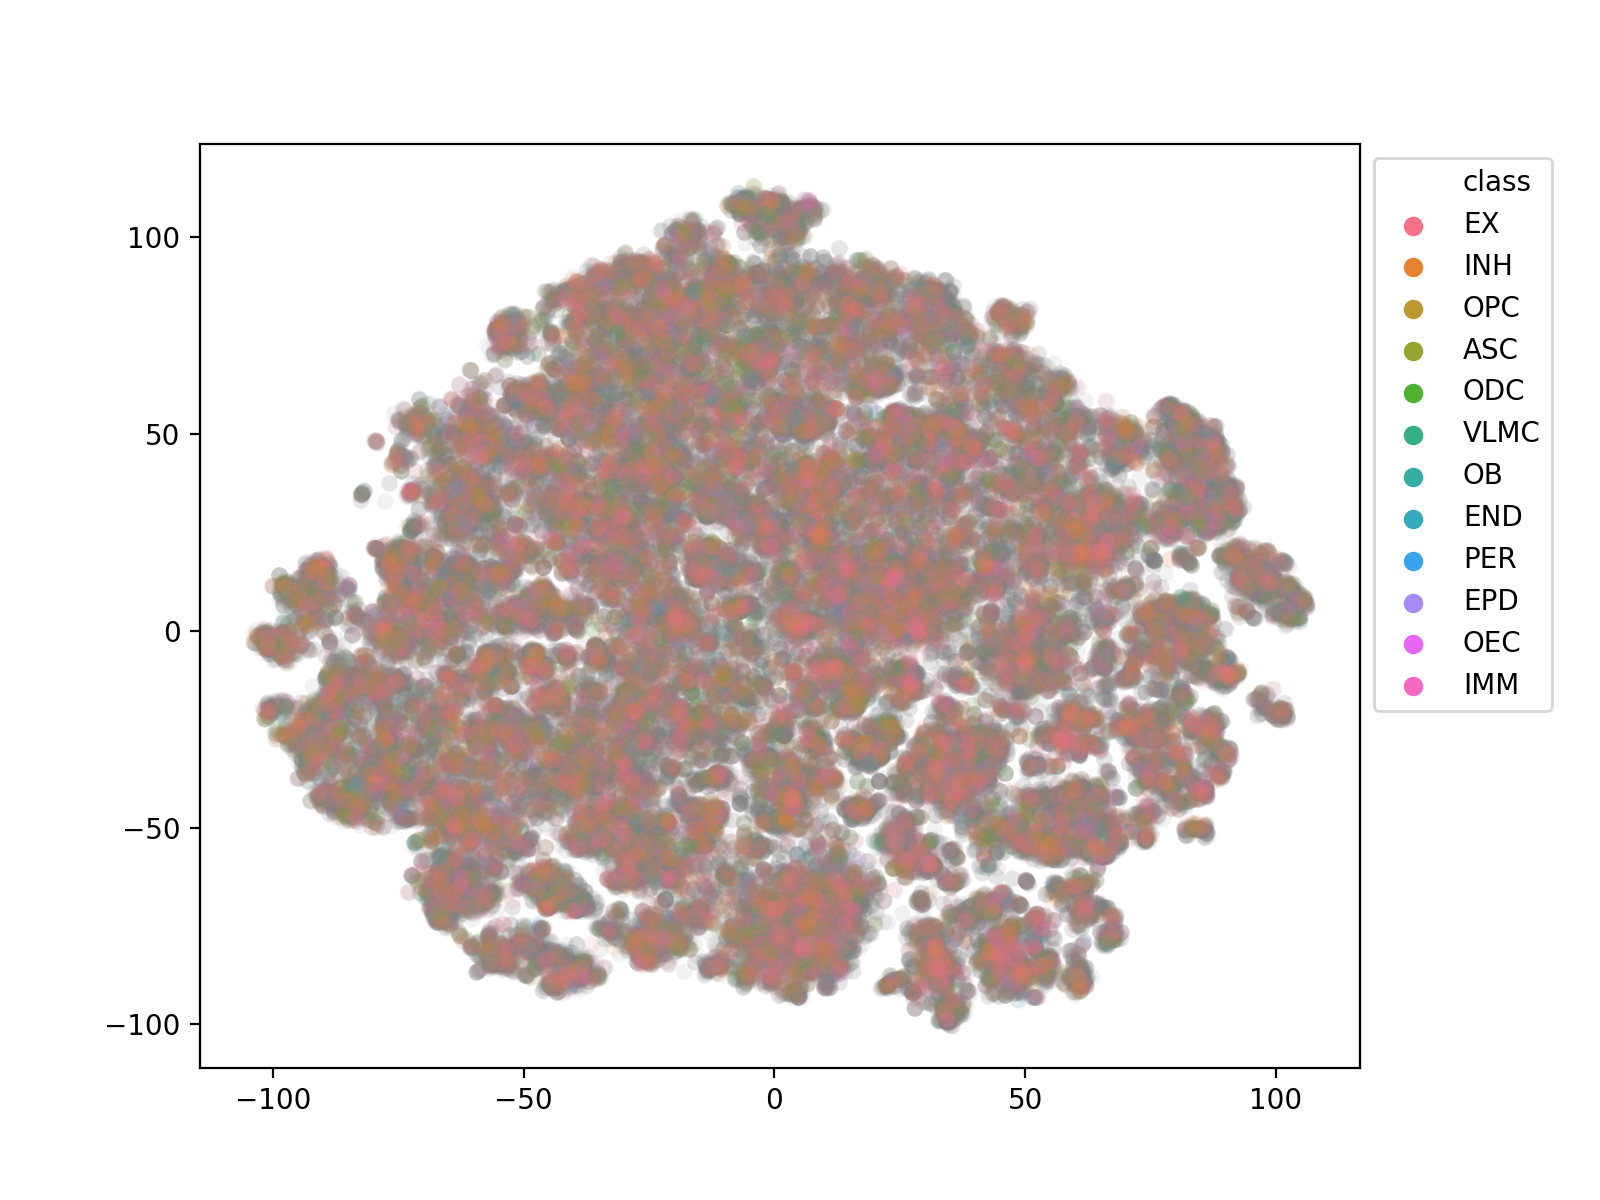

In [83]:

plt.figure(figsize = (8,6))
plt.subplots_adjust(right=0.85)
sns.scatterplot(embedding[un,0], embedding[un,1], color = 'gray', linewidth=0, alpha = 0.1)
sns.scatterplot(embedding[:,0], embedding[:,1], hue = meta_sub["class"], linewidth=0, alpha = 0.1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

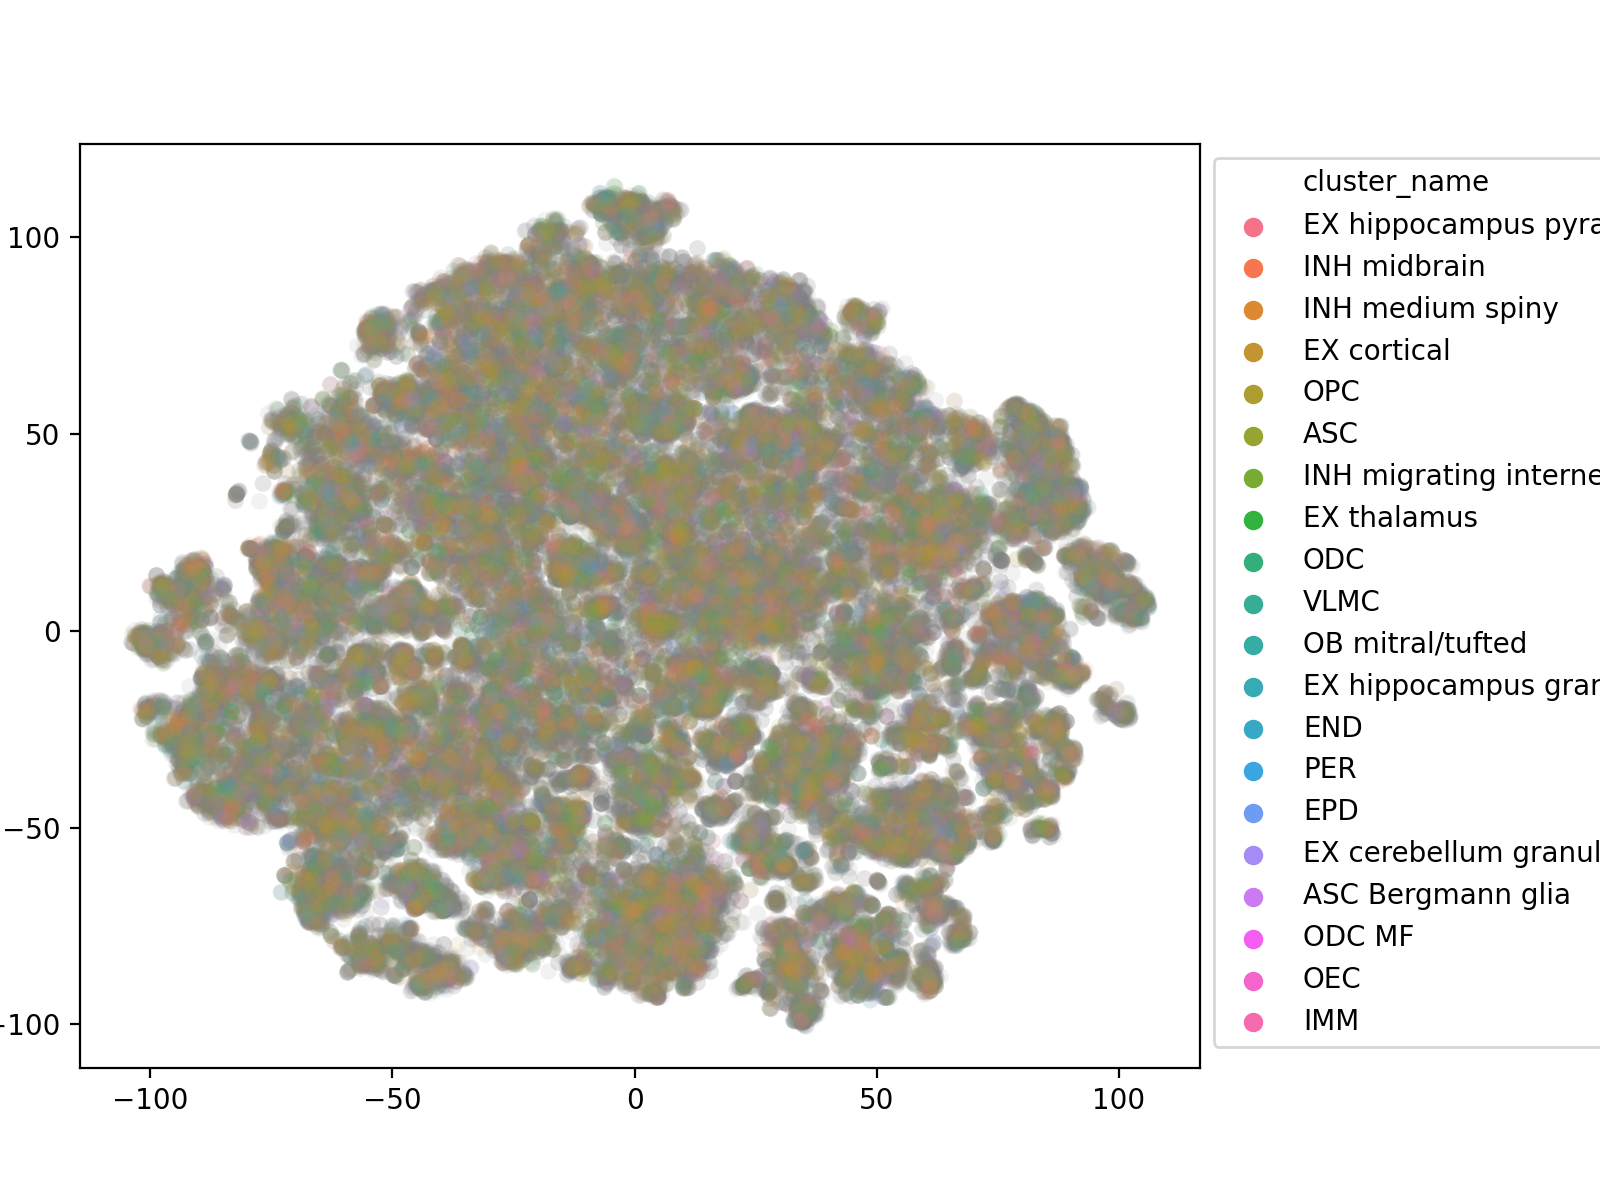

In [84]:
un = meta_sub["class"].isna()
plt.figure(figsize = (8,6))
plt.subplots_adjust(left=0.05, right=0.75)
sns.scatterplot(embedding[un,0], embedding[un,1], color = 'gray', linewidth=0, alpha = 0.1)
sns.scatterplot(embedding[:,0], embedding[:,1], hue = meta_sub["cluster_name"], linewidth=0, alpha = 0.1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

In [85]:
meta_sub

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,og_index_ranhex,CB_ranhex,no_collision,cell_sum,class,cluster_name,clusternum_anno
2,9218,AACGCTTAAGTCACTACTATTTCA,14,26,45,267560,AACGCTTAAGTCACTAATCTATAA,NaN,28692.718707,NaN,NaN,NaN
8,9224,GACAGTGCCACCTTACCTATTTCA,92,83,45,267565,GACAGTGCCACCTTACATCTATAA,True,26776.897968,EX,EX hippocampus pyramidal,15-EX hippocampus pyramidal
23,9239,CGCATACACATACCAACTATTTCA,41,34,45,267572,CGCATACACATACCAAATCTATAA,True,26649.974188,INH,INH midbrain,0-INH midbrain
25,9241,ACAGATTCGTACGCAACTATTTCA,74,55,45,267579,ACAGATTCGTACGCAAATCTATAA,True,28728.880472,INH,INH medium spiny,1-INH medium spiny
30,9246,CCATCCTCGTCTGTCACTATTTCA,84,57,45,267594,CCATCCTCGTCTGTCAATCTATAA,NaN,29178.888321,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
175605,405103,AGCACCTCCATCAAGTTACTCGAA,76,7,40,9094,AGCACCTCCATCAAGTTATCCGGG,NaN,27894.918799,NaN,NaN,NaN
175609,405107,TGAAGAGACAACCACATACTCGAA,63,29,40,9092,TGAAGAGACAACCACATATCCGGG,NaN,29615.739166,NaN,NaN,NaN
175610,405108,GCTAACGACTGGCATATACTCGAA,51,44,40,8886,GCTAACGACTGGCATATATCCGGG,NaN,27844.869405,NaN,NaN,NaN
175611,405109,GTCTGTCAACAAGCTATACTCGAA,57,9,40,8977,GTCTGTCAACAAGCTATATCCGGG,NaN,29647.903009,NaN,NaN,NaN


## Process counts matching with preproc

In [86]:
count_mat_safe = count_mat.tocsr()[meta_merged.og_index,:]

In [87]:
gene_sum = sparse_sum(count_mat_safe, 0)
cell_sum = sparse_sum(count_mat_safe, 1)

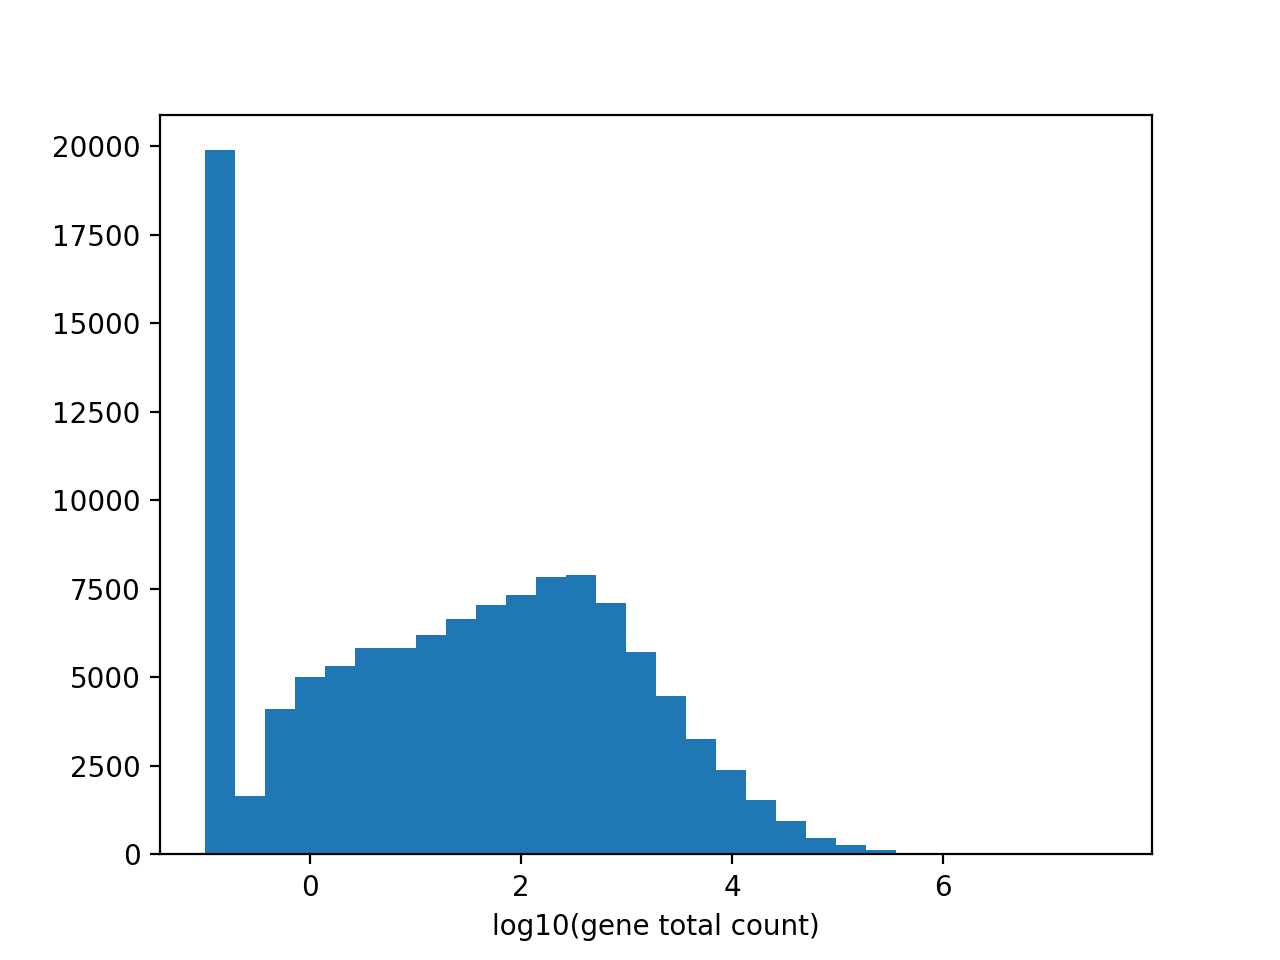

In [88]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

41.99218745

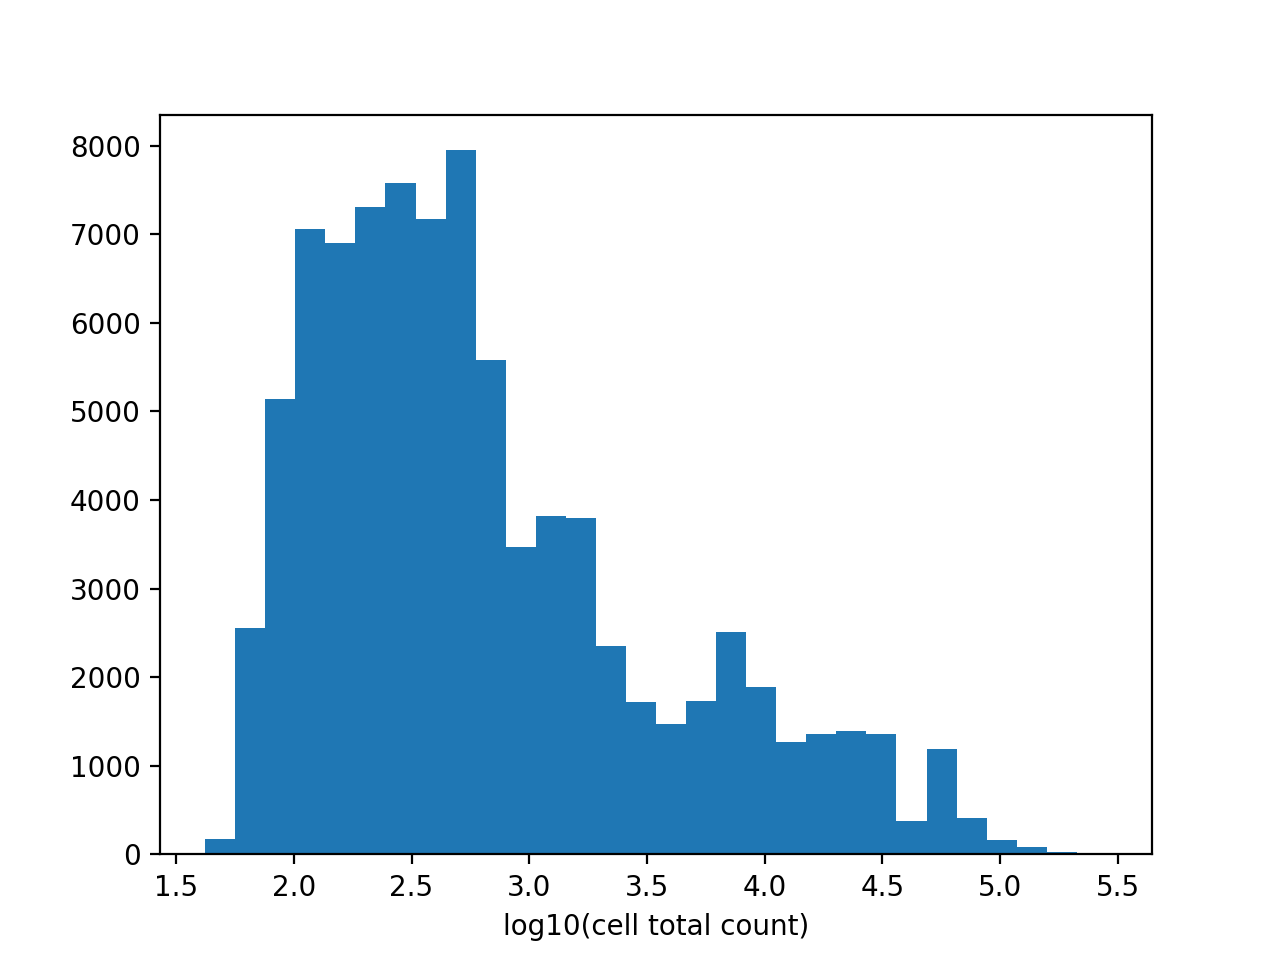

In [89]:
plt.hist(np.log10(cell_sum), 30) # i think this is probably better because the cells that weren't in preproc were probably very low coverage
plt.xlabel("log10(cell total count)")
cell_sum.min()

In [90]:
cells_to_keep = np.logical_and(cell_sum > 1000, cell_sum < 1e5) 
genes_to_keep = gene_sum > 10000
genes_to_keep.sum()

4395

In [91]:
count_sub = count_mat_safe.tocsr()[cells_to_keep,:]

In [92]:
count_sub = count_sub[:,genes_to_keep]

In [93]:
meta_merged_sub = meta_merged[cells_to_keep]
meta_merged_sub

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,...,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters,rnd3_BC_y,rnd2_BC_y,sublib_BC,full_BC_polydT,full_BC_ranhex
0,9221,GTCGTAGACGCTGATCCTATTTCA,702228,611764,205851.640,0.871176,0.336489,0.001137,17252,2625,...,ASC,ASC,5-ASC,NaN,ASC,GTCGTAGA,CGCTGATC,5,GTCGTAGACGCTGATCCTATTTCA,GTCGTAGACGCTGATCATCTATAA
1,9224,GACAGTGCCACCTTACCTATTTCA,558099,488497,194520.530,0.875287,0.398202,0.000437,18646,2722,...,EX,EX hippocampus pyramidal,15-EX hippocampus pyramidal,NaN,EX hippocampus pyramidal,GACAGTGC,CACCTTAC,6,GACAGTGCCACCTTACCTATTTCA,GACAGTGCCACCTTACATCTATAA
2,9229,CCTAATCCCACCTTACCTATTTCA,541967,463824,173348.700,0.855816,0.373738,0.000432,17367,2435,...,EX,EX cortical,13-EX cortical L2/3,NaN,EX cortical,CCTAATCC,CACCTTAC,2,CCTAATCCCACCTTACCTATTTCA,CCTAATCCCACCTTACATCTATAA
3,9236,CATACCAACTGTAGCCCTATTTCA,433821,372412,146080.780,0.858446,0.392256,0.000979,16140,2398,...,EX,EX cerebellum granule,3-EX cerebellum granule,NaN,EX cerebellum granule,CATACCAA,CTGTAGCC,7,CATACCAACTGTAGCCCTATTTCA,CATACCAACTGTAGCCATCTATAA
4,9239,CGCATACACATACCAACTATTTCA,383490,335187,139829.080,0.874044,0.417167,0.000387,17179,2416,...,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain,CGCATACA,CATACCAA,7,CGCATACACATACCAACTATTTCA,CGCATACACATACCAAATCTATAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15283,197059,GATAGACAGGAGAACACTGCTTTG,27879,23760,12150.966,0.852254,0.511404,0.000650,5304,548,...,INH,INH migrating interneuron,7-INH migrating interneuron,9-INH migrating interneuron,INH migrating interneuron,GATAGACA,GGAGAACA,7,GATAGACAGGAGAACAACTCGTAA,GATAGACAGGAGAACACTGCTTTG
15286,197062,AACGCTTAAGATGTACCTGCTTTG,27898,23993,11786.942,0.860026,0.491266,0.000724,5442,596,...,VLMC,VLMC,27-VLMC,24-VLMC,VLMC,AACGCTTA,AGATGTAC,5,AACGCTTAAGATGTACACTCGTAA,AACGCTTAAGATGTACCTGCTTTG
15289,197066,AAGGACACCGCATACACTGCTTTG,27060,23507,12539.815,0.868699,0.533450,0.004973,6035,992,...,INH,INH migrating interneuron,11-INH migrating interneuron,11-INH migrating interneuron,INH migrating interneuron,AAGGACAC,CGCATACA,7,AAGGACACCGCATACAACTCGTAA,AAGGACACCGCATACACTGCTTTG
15342,197148,GAGCTGAATAGGATGACTGCTTTG,22920,19668,9653.913,0.858115,0.490844,0.000864,4990,819,...,VLMC,VLMC,35-VLMC,24-VLMC,VLMC,GAGCTGAA,TAGGATGA,5,GAGCTGAATAGGATGAACTCGTAA,GAGCTGAATAGGATGACTGCTTTG


In [94]:
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 

In [95]:
ge = np.log10(rat.toarray() + 1.)

In [96]:

scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

<Axes: >

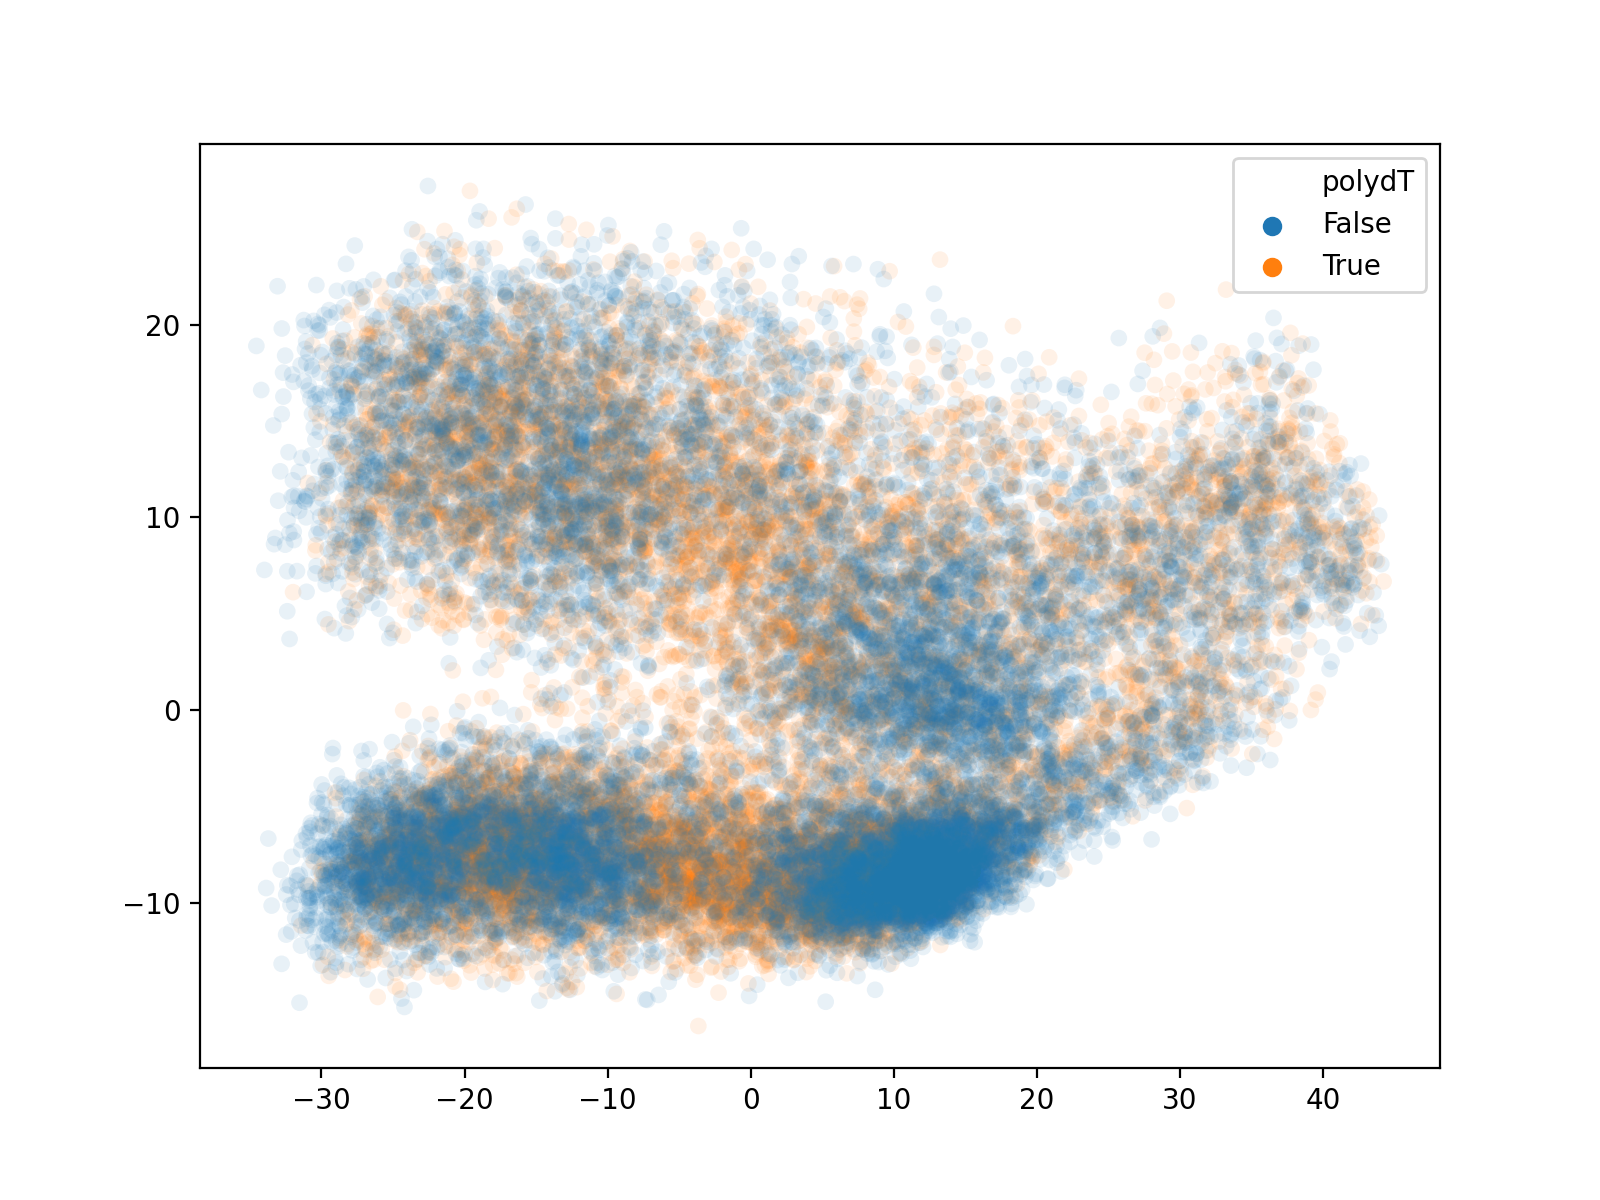

In [97]:
plt.figure(figsize=(8,6))
sns.scatterplot(low_rank_data[:,0], low_rank_data[:,1], hue = meta_merged_sub["polydT"], linewidth=0, alpha = 0.1)

<Axes: >

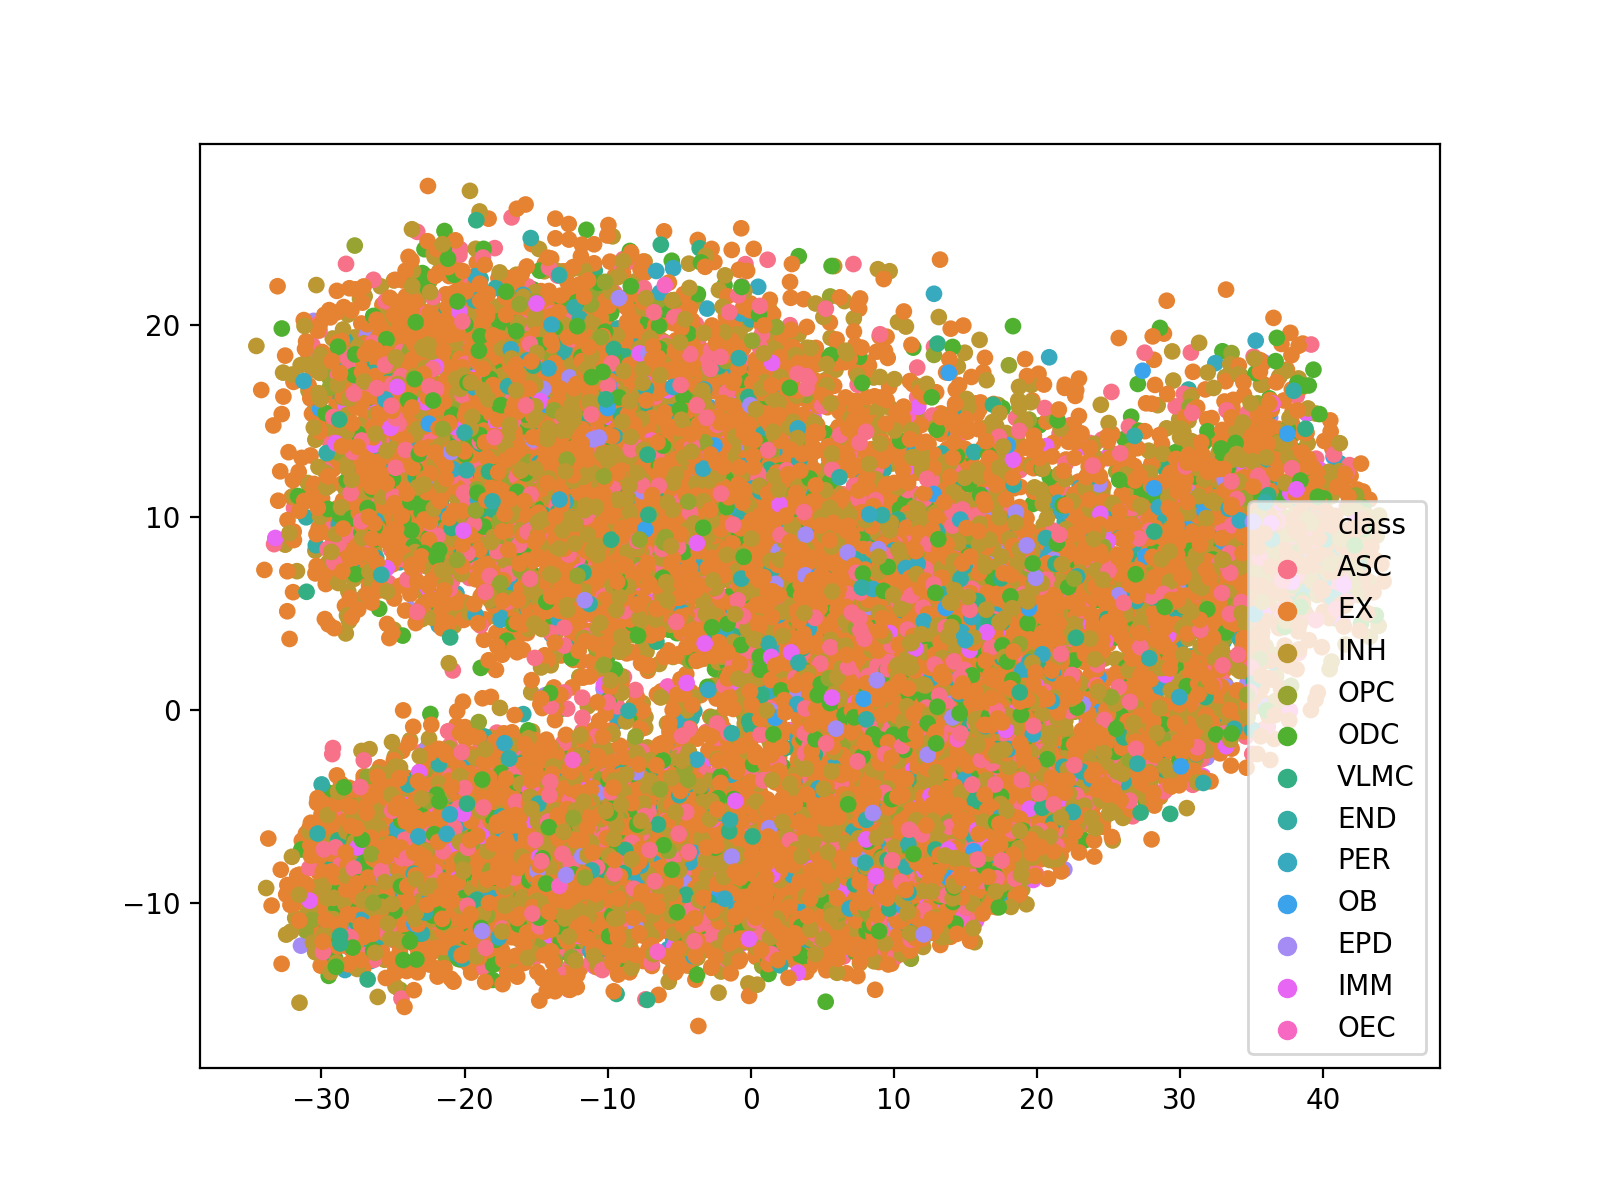

In [98]:
plt.figure(figsize=(8,6))
sns.scatterplot(low_rank_data[:,0], low_rank_data[:,1], hue = meta_merged_sub["class"], linewidth=0)

In [99]:
tsne = TSNE(n_components=2)
embedding = tsne.fit_transform(low_rank_data)

AttributeError: 'NoneType' object has no attribute 'split'

<Axes: >

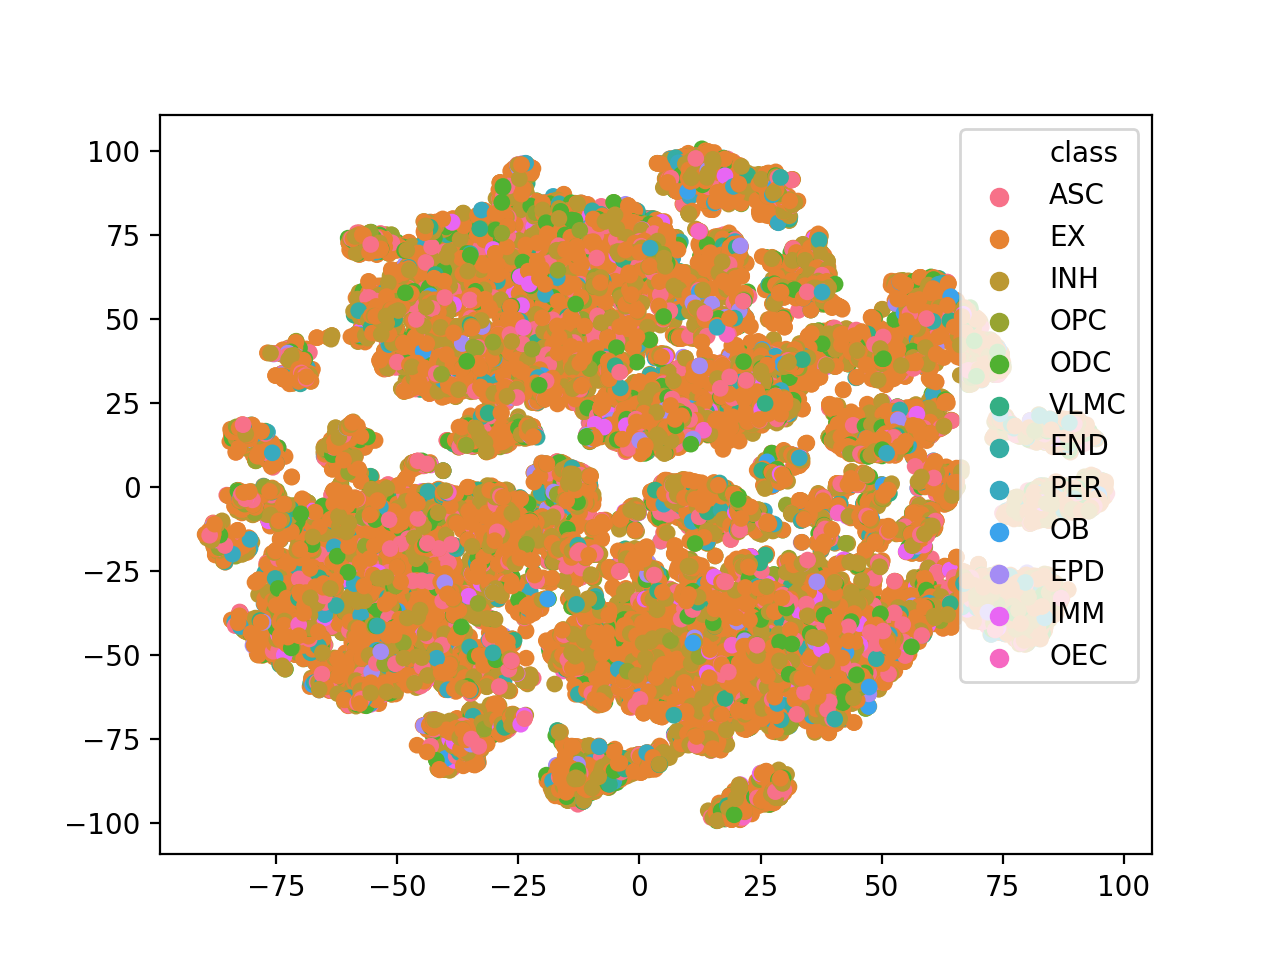

In [100]:
sns.scatterplot(embedding[:,0], embedding[:,1], hue = meta_merged_sub["class"], linewidth=0)

<Axes: >

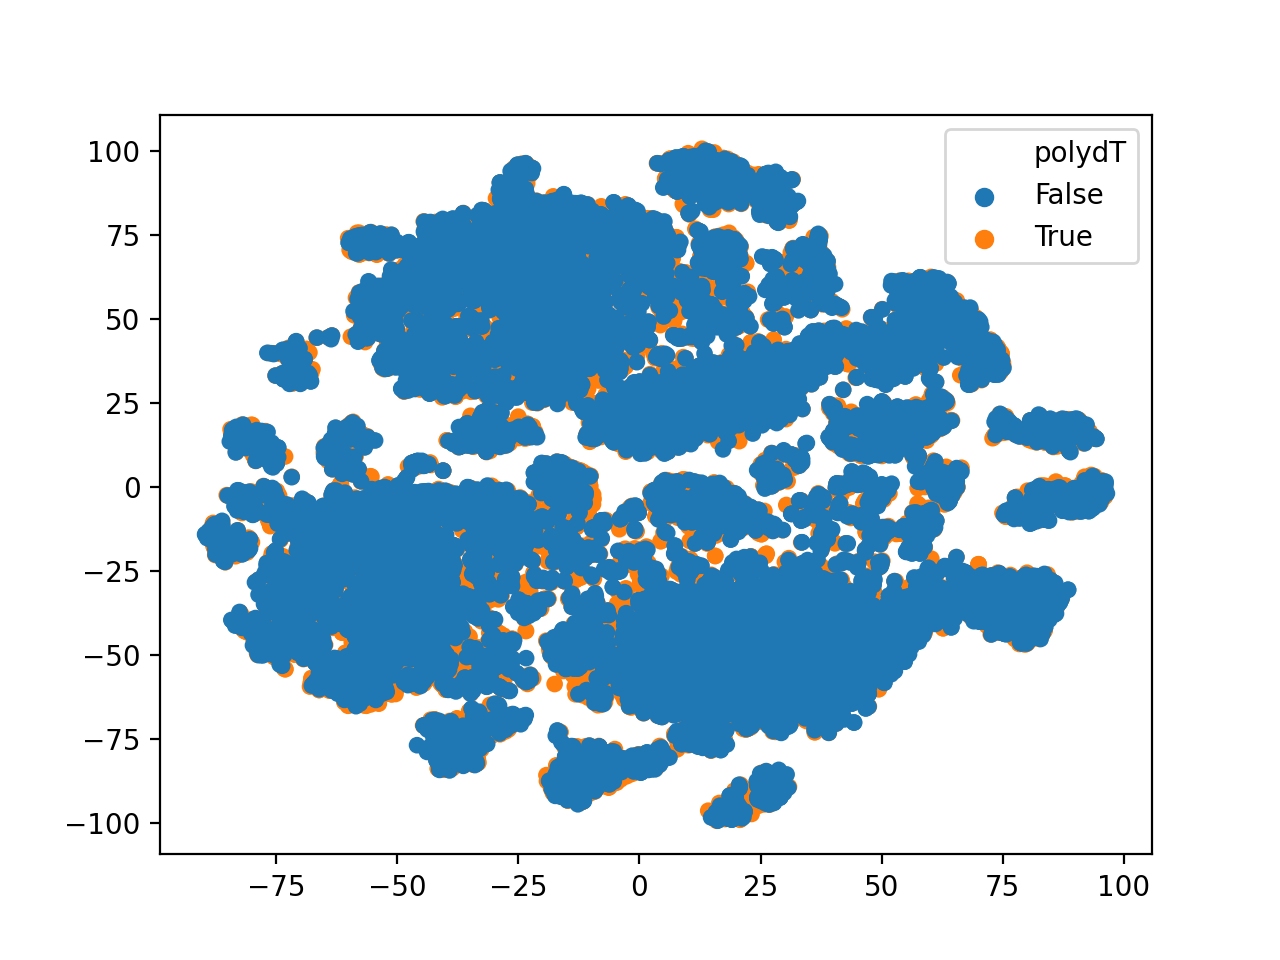

In [101]:
sns.scatterplot(embedding[:,0], embedding[:,1], hue = meta_merged_sub["polydT"], linewidth=0)

## Combine polydT and ranhex

In [102]:
meta_merged.columns

Index(['og_index', 'CB', 'CorrectedReads', 'MappedReads', 'DeduplicatedReads',
       'MappingRate', 'DedupRate', 'MeanByMax', 'NumGenesExpressed',
       'NumGenesOverMean', 'rnd3_BC_x', 'rnd2_BC_x', 'rnd1_BC', 'rnd2_well_x',
       'rnd3_well_x', 'rnd1_well_x', 'polydT', 'nCount_RNA', 'nFeature_RNA',
       'sample', 'rnd1_well_y', 'rnd2_well_y', 'rnd3_well_y', 'sublibrary',
       'RNA.Nuclei.Group', 'Age', 'Sex', 'Sac', 'Dissection.Batch', 'DX',
       'RIN', 'percent.mt', 'class', 'cluster_name', 'clusternum_anno',
       'clusters_4conditions', 'cellchat_clusters', 'rnd3_BC_y', 'rnd2_BC_y',
       'sublib_BC', 'full_BC_polydT', 'full_BC_ranhex'],
      dtype='object')

In [103]:
#a = meta_merged[['rnd1_well', 'rnd2_well', 'rnd3_well', 'sublibrary']]
# only 9k having matching polydt and ranhex when using permit_knee. With permit_known almost all match, yay! 
repeat_counts = meta_merged.groupby(['rnd1_well', 'rnd2_well', 'rnd3_well', 'sublibrary']).size().reset_index(name = 'count') 
repeat_counts["count"].value_counts()

KeyError: 'rnd1_well'

In [ ]:
matches = repeat_counts[ repeat_counts["count"]==2 ]
del matches["count"]

polydT_meta = pd.merge(matches, meta_merged[meta_merged.polydT], on = ['rnd1_well', 'rnd2_well', 'rnd3_well', 'sublibrary'], how = "inner")
ranhex_meta = pd.merge(matches, meta_merged[~meta_merged.polydT], on = ['rnd1_well', 'rnd2_well', 'rnd3_well', 'sublibrary'], how = "inner")

In [ ]:
(polydT_meta.rnd1_well == ranhex_meta.rnd1_well).all() # good, order is the same

In [ ]:
polydT_counts = count_mat.tocsr()[polydT_meta.og_index,:]
ranhex_counts = count_mat.tocsr()[ranhex_meta.og_index,:]
comb_counts = polydT_counts + ranhex_counts

In [ ]:
comb_counts.shape

In [ ]:
gene_sum = sparse_sum(comb_counts, 0)
cell_sum = sparse_sum(comb_counts, 1)

In [ ]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

In [ ]:
plt.hist(np.log10(cell_sum), 30)
plt.xlabel("log10(cell total count)")
cell_sum.min()

In [ ]:
cells_to_keep = np.logical_and(cell_sum > 1000, cell_sum < 1e5)
genes_to_keep = gene_sum > 10000
genes_to_keep.sum()

In [ ]:
count_sub = comb_counts[cells_to_keep,:]

In [ ]:
count_sub = count_sub[:,genes_to_keep]


In [ ]:
meta_sub = polydT_meta[cells_to_keep]
meta_sub

In [ ]:
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 

In [ ]:
ge = np.log10(rat.toarray() + 1.)

In [ ]:
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(low_rank_data[:,0], low_rank_data[:,1], hue = meta_sub["class"], linewidth=0)

In [ ]:

tsne = TSNE(n_components=2)
embedding = tsne.fit_transform(low_rank_data)

In [ ]:
sns.scatterplot(embedding[:,0], embedding[:,1], hue = meta_sub["class"], linewidth=0)

If I try random mapping of polydT and ranhex then I just get a ball in PCA space. 
Actually I think it has to be correct because the cell clustering wouldn't have shown up for the half cells otherwise. 

In [ ]:
preproc_cellmeta